In [30]:
# ============================================================
# LOAD OLD FULL CVAE+GNO WRAPPER, THEN TRAIN NEW PHYSICAL HEAD
# ============================================================

import os
import torch
from beam_global_model import *

device = get_device()

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
DATA_PATH = "/home/martinez/ML4CollEffects/notebooks/50_VAE/neural_xsuite_dataset_2026-04-28T09_40_32.npz"

# This must be the old FULL wrapper checkpoint:
# BeamLatentGNOModel(...).state_dict()
FULL_DISTRIBUTION_CKPT = "/home/martinez/ML4CollEffects/notebooks/60_CVAE_GNO/trained_beam_latent_GNO_model.pth"

SAVE_GLOBAL_MODEL = "/home/martinez/ML4CollEffects/notebooks/60_CVAE_GNO/global_physical_CVAE_GNO_stats.pth"
SAVE_STATS_HEAD = "/home/martinez/ML4CollEffects/notebooks/60_CVAE_GNO/physical_stats_head_only.pth"

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
data = load_npz(DATA_PATH)

train_loader, val_loader, test_loader = make_loaders(
    data,
    batch_size=16,
)

mu_dim = data["MU"].shape[-1]

mu_prep = MUPreprocessor(
    MUPreprocessConfig(
        specs=[1.0] * mu_dim,
        standardize=True,
    )
)
mu_prep.fit(data["MU"])
mu_prep.to(device)

# ------------------------------------------------------------
# New global model:
#   distribution = old CVAE+GNO wrapper
#   stats_head   = new physical moment head
# ------------------------------------------------------------
model = GlobalPhysicalBeamModel(
    mu_dim=mu_dim,
    latent_dim=512,
    d_model=512,
    domain_dim=2,
    nbins=64,
    gno_layers=4,
    stats_include_latent=True,
).to(device)

# ------------------------------------------------------------
# Load old full wrapper into the distribution branch
# ------------------------------------------------------------
def extract_state_dict(ckpt):
    if isinstance(ckpt, dict):
        for key in ["state_dict", "model_state_dict", "model", "net"]:
            if key in ckpt and isinstance(ckpt[key], dict):
                return ckpt[key]
    return ckpt

def load_old_full_wrapper_into_distribution(model, ckpt_path):
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(ckpt_path)

    ckpt = torch.load(ckpt_path, map_location=device)
    old_sd = extract_state_dict(ckpt)

    if not isinstance(old_sd, dict):
        raise RuntimeError("Checkpoint is not a valid state_dict.")

    target_sd = model.distribution.state_dict()
    filtered = {}

    for k, v in old_sd.items():
        kk = k

        # handle checkpoints saved as model.xxx or module.xxx
        for prefix in ["module.", "model.", "net.", "distribution."]:
            if kk.startswith(prefix):
                kk = kk[len(prefix):]

        # old full wrapper keys like:
        #   vae.xxx
        #   tokenizer.xxx
        #   tracker.xxx
        #   mu_to_z.xxx
        # should match model.distribution.xxx
        if kk in target_sd and hasattr(v, "shape") and target_sd[kk].shape == v.shape:
            filtered[kk] = v

    missing, unexpected = model.distribution.load_state_dict(filtered, strict=False)

    print(f"Loaded {len(filtered)}/{len(target_sd)} tensors into model.distribution")
    print(f"Missing keys: {len(missing)}")
    print(f"Unexpected keys: {len(unexpected)}")

    ignored = [k for k in old_sd.keys() if k not in filtered]
    print("\nSome ignored old checkpoint keys:")
    for k in ignored[:20]:
        print(" ", k)

    if len(filtered) == 0:
        raise RuntimeError(
            "Loaded 0 tensors. This probably means the checkpoint is Transformer, "
            "or the architecture/key names do not match."
        )

load_old_full_wrapper_into_distribution(model, FULL_DISTRIBUTION_CKPT)
# ============================================================
# CLEAN STABLE STATS-HEAD TRAINING
#
# Use this after:
#   load_old_full_wrapper_into_distribution(model, FULL_DISTRIBUTION_CKPT)
#
# Main idea:
#   Replace stats_head with a fresh head that directly predicts:
#
#       delta_log_sigma_hat        = log(sigma_N) - log(sigma_0)
#       delta_centroid_scaled_hat  = (centroid_N - centroid_0) / sigma_0
#
# Then reconstruct:
#
#       sigma_N    = sigma_0 * exp(delta_log_sigma_hat)
#       centroid_N = centroid_0 + sigma_0 * delta_centroid_scaled_hat
#
# ============================================================

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from types import SimpleNamespace

EPS = 1e-12


# ============================================================
# 1. CLEAN NORMALIZED STATS HEAD
# ============================================================

class NormalizedMomentTransportHead(nn.Module):
    def __init__(
        self,
        mu_dim,
        hidden_dim=384,
        n_layers=4,
        dropout=0.05,
        include_latent=True,
        latent_dim=512,
        eps=1e-12,
    ):
        super().__init__()

        self.cfg = SimpleNamespace(
            include_latent=include_latent,
            latent_dim=latent_dim,
            eps=eps,
        )

        self.eps = eps

        # inputs:
        #   log_sigma0        [6]
        #   centroid0/sigma0 [6]
        #   MU_enc           [mu_dim]
        #   z_context        [latent_dim] optional
        in_dim = 12 + mu_dim + (latent_dim if include_latent else 0)

        layers = [
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        ]

        for _ in range(n_layers - 1):
            layers += [
                nn.Linear(hidden_dim, hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            ]

        self.backbone = nn.Sequential(*layers)

        # output:
        #   first 6  -> delta_log_sigma
        #   last 6   -> delta_centroid_scaled
        self.out = nn.Linear(hidden_dim, 12)

        # Start near identity transport:
        #   delta_log_sigma = 0
        #   delta_centroid_scaled = 0
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(
        self,
        sigma0,
        centroid0,
        MU_enc,
        z_context=None,
    ):
        sigma0_safe = torch.clamp(
            sigma0,
            min=self.eps,
        )

        log_sigma0 = torch.log(
            sigma0_safe,
        )

        centroid0_scaled = (
            centroid0
            /
            sigma0_safe
        )

        features = [
            log_sigma0,
            centroid0_scaled,
            MU_enc,
        ]

        if self.cfg.include_latent:
            if z_context is None:
                z_context = torch.zeros(
                    sigma0.shape[0],
                    self.cfg.latent_dim,
                    device=sigma0.device,
                    dtype=sigma0.dtype,
                )

            features.append(
                z_context,
            )

        h = torch.cat(
            features,
            dim=-1,
        )

        raw = self.out(
            self.backbone(h)
        )

        delta_log_sigma_hat = raw[:, :6]
        delta_centroid_scaled_hat = raw[:, 6:]

        log_sigmaN_hat = (
            log_sigma0
            +
            delta_log_sigma_hat
        )

        sigmaN_hat = torch.exp(
            log_sigmaN_hat,
        ).clamp_min(
            self.eps,
        )

        centroidN_hat = (
            centroid0
            +
            delta_centroid_scaled_hat * sigma0_safe
        )

        return {
            "delta_log_sigma_hat": delta_log_sigma_hat,
            "delta_centroid_scaled_hat": delta_centroid_scaled_hat,

            "log_sigmaN_hat": log_sigmaN_hat,
            "sigmaN_hat": sigmaN_hat,
            "centroidN_hat": centroidN_hat,

            "delta_centroid_hat": centroidN_hat - centroid0,
        }


# Replace bad/old stats head
model.stats_head = NormalizedMomentTransportHead(
    mu_dim=mu_dim,
    hidden_dim=384,
    n_layers=4,
    dropout=0.05,
    include_latent=True,
    latent_dim=512,
    eps=EPS,
).to(device)

model.train_only_stats_head()
model.distribution.eval()

for p in model.distribution.parameters():
    p.requires_grad_(False)


# ============================================================
# 2. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    trainable_parameters(model),
    lr=2e-4,
    weight_decay=1e-6,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=12,
    min_lr=1e-6,
)


# ============================================================
# 3. HELPERS
# ============================================================

def make_domain_from_mu(MU, model):
    domain_dim = model.distribution.domain_dim

    if MU.shape[1] >= domain_dim:
        return MU[:, :domain_dim]

    return torch.zeros(
        MU.shape[0],
        domain_dim,
        device=MU.device,
        dtype=MU.dtype,
    )


def make_tokens(B, device, lattice="fodo", N_elem=3):
    if lattice == "fodo":
        return make_fodo_lattice_tokens(
            B,
            N_elem,
            device,
        )

    return make_dummy_lattice_tokens(
        B,
        N_elem,
        device,
    )


def weighted_smooth_l1(
    residual,
    coord_weights,
    beta=0.25,
):
    loss = F.smooth_l1_loss(
        residual,
        torch.zeros_like(residual),
        beta=beta,
        reduction="none",
    )

    loss = loss * coord_weights[None, :]

    return loss.mean()


# ============================================================
# 4. MODERATE COORDINATE WEIGHTS
# ============================================================

# Mildly help sigma_delta, but do not over-force it.
SIGMA_WEIGHTS = torch.tensor(
    [1.0, 1.0, 1.0, 1.0, 1.0, 2.5],
    device=device,
)

# Mildly help centroids except <delta>, but not aggressively.
CENTROID_WEIGHTS = torch.tensor(
    [2.0, 2.0, 2.0, 2.0, 2.0, 1.0],
    device=device,
)

W_DLOG = 1.0
W_DMU = 5.0
W_FINAL_SIGMA = 0.25
W_FINAL_MU = 0.50


# ============================================================
# 5. CLEAN LOSS
# ============================================================

def physical_head_loss(out, X, Y):
    centroid0, sigma0 = beam_centroid_sigma(X)
    centroidY, sigmaY = beam_centroid_sigma(Y)

    sigma0 = torch.clamp(
        sigma0,
        min=EPS,
    )

    sigmaY = torch.clamp(
        sigmaY,
        min=EPS,
    )

    log_sigma0 = torch.log(
        sigma0,
    )

    log_sigmaY = torch.log(
        sigmaY,
    )

    # --------------------------------------------------------
    # Normalized targets
    # --------------------------------------------------------
    target_dlog = (
        log_sigmaY
        -
        log_sigma0
    )

    target_dmu = (
        centroidY
        -
        centroid0
    ) / sigma0.detach()

    # --------------------------------------------------------
    # Predictions from the new head
    # --------------------------------------------------------
    pred_dlog = out["delta_log_sigma_hat"]

    pred_dmu = out["delta_centroid_scaled_hat"]

    # --------------------------------------------------------
    # Main normalized residuals
    # --------------------------------------------------------
    dlog_residual = (
        pred_dlog
        -
        target_dlog.detach()
    )

    dmu_residual = (
        pred_dmu
        -
        target_dmu.detach()
    )

    dlog_loss = weighted_smooth_l1(
        dlog_residual,
        SIGMA_WEIGHTS,
        beta=0.25,
    )

    dmu_loss = weighted_smooth_l1(
        dmu_residual,
        CENTROID_WEIGHTS,
        beta=0.25,
    )

    # --------------------------------------------------------
    # Small physical anchors
    # --------------------------------------------------------
    final_sigma_residual = (
        out["log_sigmaN_hat"]
        -
        log_sigmaY.detach()
    )

    final_sigma_loss = weighted_smooth_l1(
        final_sigma_residual,
        SIGMA_WEIGHTS,
        beta=0.25,
    )

    final_mu_residual = (
        out["centroidN_hat"]
        -
        centroidY
    ) / sigmaY.detach()

    final_mu_loss = weighted_smooth_l1(
        final_mu_residual,
        CENTROID_WEIGHTS,
        beta=0.25,
    )

    loss = (
        W_DLOG * dlog_loss
        +
        W_DMU * dmu_loss
        +
        W_FINAL_SIGMA * final_sigma_loss
        +
        W_FINAL_MU * final_mu_loss
    )

    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------
    sigma_rel_per_coord = torch.mean(
        torch.abs(
            out["sigmaN_hat"] - sigmaY
        ) / sigmaY.detach(),
        dim=0,
    )

    mu_rms_sigma_per_coord = torch.sqrt(
        torch.mean(
            final_mu_residual ** 2,
            dim=0,
        )
    )

    dlog_rms_per_coord = torch.sqrt(
        torch.mean(
            dlog_residual ** 2,
            dim=0,
        )
    )

    dmu_rms_per_coord = torch.sqrt(
        torch.mean(
            dmu_residual ** 2,
            dim=0,
        )
    )

    sigma_rel = sigma_rel_per_coord.mean()

    centroid_rms_sigma = torch.sqrt(
        torch.mean(
            final_mu_residual ** 2,
            dim=1,
        )
    ).mean()

    dlog_rms = torch.sqrt(
        torch.mean(
            dlog_residual ** 2,
            dim=1,
        )
    ).mean()

    dmu_rms = torch.sqrt(
        torch.mean(
            dmu_residual ** 2,
            dim=1,
        )
    ).mean()

    centroid_abs = torch.mean(
        torch.abs(
            out["centroidN_hat"]
            -
            centroidY
        )
    )

    return {
        "loss": loss,

        "dlog_loss": dlog_loss.detach(),
        "dmu_loss": dmu_loss.detach(),
        "final_sigma_loss": final_sigma_loss.detach(),
        "final_mu_loss": final_mu_loss.detach(),

        "sigma_rel": sigma_rel.detach(),
        "centroid_rms_sigma": centroid_rms_sigma.detach(),
        "delta_log_sigma_rms": dlog_rms.detach(),
        "delta_centroid_scaled_rms": dmu_rms.detach(),
        "centroid_abs": centroid_abs.detach(),

        "sigma_rel_per_coord": sigma_rel_per_coord.detach(),
        "mu_rms_sigma_per_coord": mu_rms_sigma_per_coord.detach(),
        "dlog_rms_per_coord": dlog_rms_per_coord.detach(),
        "dmu_rms_per_coord": dmu_rms_per_coord.detach(),
    }


# ============================================================
# 6. METRIC ACCUMULATION
# ============================================================

def init_metric_totals():
    return {
        "loss": 0.0,
        "dlog_loss": 0.0,
        "dmu_loss": 0.0,
        "final_sigma_loss": 0.0,
        "final_mu_loss": 0.0,

        "sigma_rel": 0.0,
        "centroid_rms_sigma": 0.0,
        "delta_log_sigma_rms": 0.0,
        "delta_centroid_scaled_rms": 0.0,
        "centroid_abs": 0.0,

        "sigma_rel_per_coord": torch.zeros(6),
        "mu_rms_sigma_per_coord": torch.zeros(6),
        "dlog_rms_per_coord": torch.zeros(6),
        "dmu_rms_per_coord": torch.zeros(6),
    }


def accumulate_metrics(totals, metrics):
    for k, v in metrics.items():
        if isinstance(v, torch.Tensor) and v.ndim > 0:
            totals[k] += v.detach().cpu()
        else:
            totals[k] += float(v.detach().cpu())


def average_metric_totals(totals, n_batches):
    out = {}

    for k, v in totals.items():
        if isinstance(v, torch.Tensor):
            out[k] = (v / max(n_batches, 1)).numpy()
        else:
            out[k] = v / max(n_batches, 1)

    return out


# ============================================================
# 7. TRAIN / EVALUATE
# ============================================================

def train_physical_head_epoch(
    model,
    loader,
    optimizer,
    mu_prep,
    device,
    N_elem=3,
    lattice="fodo",
    grad_clip=1.0,
):
    model.train()
    model.distribution.eval()

    totals = init_metric_totals()
    n_batches = 0

    for X, Y, MU in loader:
        X = X.to(device)
        Y = Y.to(device)
        MU = MU.to(device)

        MU_enc = mu_prep(MU) if mu_prep is not None else MU
        domain = make_domain_from_mu(MU, model)

        elem_params, elem_s = make_tokens(
            X.shape[0],
            device,
            lattice=lattice,
            N_elem=N_elem,
        )

        optimizer.zero_grad(set_to_none=True)

        out = model(
            X,
            MU_enc,
            elem_params,
            elem_s,
            domain,
            sample_vae=False,
            return_physical_density=False,
        )

        metrics = physical_head_loss(
            out,
            X,
            Y,
        )

        metrics["loss"].backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(
                list(trainable_parameters(model)),
                grad_clip,
            )

        optimizer.step()

        accumulate_metrics(
            totals,
            metrics,
        )

        n_batches += 1

    return average_metric_totals(
        totals,
        n_batches,
    )


@torch.no_grad()
def evaluate_physical_head(
    model,
    loader,
    mu_prep,
    device,
    N_elem=3,
    lattice="fodo",
):
    model.eval()

    totals = init_metric_totals()
    n_batches = 0

    for X, Y, MU in loader:
        X = X.to(device)
        Y = Y.to(device)
        MU = MU.to(device)

        MU_enc = mu_prep(MU) if mu_prep is not None else MU
        domain = make_domain_from_mu(MU, model)

        elem_params, elem_s = make_tokens(
            X.shape[0],
            device,
            lattice=lattice,
            N_elem=N_elem,
        )

        out = model(
            X,
            MU_enc,
            elem_params,
            elem_s,
            domain,
            sample_vae=False,
            return_physical_density=False,
        )

        metrics = physical_head_loss(
            out,
            X,
            Y,
        )

        accumulate_metrics(
            totals,
            metrics,
        )

        n_batches += 1

    return average_metric_totals(
        totals,
        n_batches,
    )


# ============================================================
# 8. TRAIN LOOP
# ============================================================

best_val = float("inf")
best_state = None
history = []

coord_names = list(COORD_NAMES)

for epoch in range(150):
    train_metrics = train_physical_head_epoch(
        model,
        train_loader,
        optimizer,
        mu_prep,
        device,
        N_elem=3,
        lattice="fodo",
        grad_clip=1.0,
    )

    val_metrics = evaluate_physical_head(
        model,
        val_loader,
        mu_prep,
        device,
        N_elem=3,
        lattice="fodo",
    )

    val_score = (
        1.0 * val_metrics["delta_centroid_scaled_rms"]
        +
        0.50 * val_metrics["centroid_rms_sigma"]
        +
        0.25 * val_metrics["delta_log_sigma_rms"]
        +
        0.10 * val_metrics["sigma_rel_per_coord"][5]
    )

    scheduler.step(
        val_score,
    )

    history.append(
        {
            "epoch": epoch,
            "train": train_metrics,
            "val": val_metrics,
            "score": val_score,
            "lr": optimizer.param_groups[0]["lr"],
        }
    )

    if val_score < best_val:
        best_val = val_score

        best_state = {
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "distribution_state_dict": copy.deepcopy(model.distribution.state_dict()),
            "stats_head_state_dict": copy.deepcopy(model.stats_head.state_dict()),
            "mu_prep_state_dict": copy.deepcopy(mu_prep.state_dict()),

            "epoch": epoch,
            "best_val": best_val,
            "history": history,

            "loss_weights": {
                "W_DLOG": W_DLOG,
                "W_DMU": W_DMU,
                "W_FINAL_SIGMA": W_FINAL_SIGMA,
                "W_FINAL_MU": W_FINAL_MU,
                "SIGMA_WEIGHTS": SIGMA_WEIGHTS.detach().cpu(),
                "CENTROID_WEIGHTS": CENTROID_WEIGHTS.detach().cpu(),
            },

            "config": {
                "mu_dim": mu_dim,
                "latent_dim": 512,
                "d_model": 512,
                "domain_dim": 2,
                "nbins": 64,
                "gno_layers": 4,
                "stats_include_latent": True,
            },
        }

    sigma_rel_pc = val_metrics["sigma_rel_per_coord"]
    mu_rms_pc = val_metrics["mu_rms_sigma_per_coord"]

    sigma_rel_txt = " ".join(
        [
            f"{coord_names[i]}={sigma_rel_pc[i]:.2e}"
            for i in range(6)
        ]
    )

    mu_rms_txt = " ".join(
        [
            f"{coord_names[i]}={mu_rms_pc[i]:.2e}"
            for i in range(6)
        ]
    )

    print(
        f"epoch {epoch:03d} | "
        f"lr {optimizer.param_groups[0]['lr']:.1e} | "
        f"train {train_metrics['loss']:.4e} | "
        f"score {val_score:.4e} | "
        f"dlog {val_metrics['delta_log_sigma_rms']:.4e} | "
        f"dmu {val_metrics['delta_centroid_scaled_rms']:.4e} | "
        f"mu/sigma {val_metrics['centroid_rms_sigma']:.4e} | "
        f"sigma_delta_rel {val_metrics['sigma_rel_per_coord'][5]:.4e} | "
        f"mu_abs {val_metrics['centroid_abs']:.4e}"
    )

    print("  sigma_rel per coord:", sigma_rel_txt)
    print("  mu/sigma per coord: ", mu_rms_txt)


# ============================================================
# 9. SAVE
# ============================================================

model.load_state_dict(
    best_state["model_state_dict"],
    strict=True,
)

model.eval()

torch.save(
    best_state,
    SAVE_GLOBAL_MODEL,
)

torch.save(
    best_state["stats_head_state_dict"],
    SAVE_STATS_HEAD,
)

print("\nDONE.")
print(f"Best epoch: {best_state['epoch']}")
print(f"Best val score: {best_state['best_val']:.4e}")
print("Saved full physical model:")
print(SAVE_GLOBAL_MODEL)
print("\nSaved stats head only:")
print(SAVE_STATS_HEAD)

Loaded 133/149 tensors into model.distribution
Missing keys: 16
Unexpected keys: 0

Some ignored old checkpoint keys:
  tracker.gno_layers.0.post_conv.weight
  tracker.gno_layers.0.post_conv.bias
  tracker.gno_layers.1.post_conv.weight
  tracker.gno_layers.1.post_conv.bias
  tracker.gno_layers.2.post_conv.weight
  tracker.gno_layers.2.post_conv.bias
  tracker.gno_layers.3.post_conv.weight
  tracker.gno_layers.3.post_conv.bias
  track_logsigma_head.0.weight
  track_logsigma_head.0.bias
  track_logsigma_head.2.weight
  track_logsigma_head.2.bias
  track_centroid_head.0.weight
  track_centroid_head.0.bias
  track_centroid_head.2.weight
  track_centroid_head.2.bias
epoch 000 | lr 2.0e-04 | train 3.0129e+01 | score 1.5981e+01 | dlog 6.8112e-01 | dmu 1.5347e+01 | mu/sigma 6.7090e-01 | sigma_delta_rel 1.2795e+00 | mu_abs 8.8340e-04
  sigma_rel per coord: x=1.50e+00 px=1.52e+00 y=5.49e-02 py=1.20e-07 zeta=1.26e-07 delta=1.28e+00
  mu/sigma per coord:  x=1.21e-02 px=1.36e-02 y=2.19e-02 py=0.00e

In [40]:
# ============================================================
# TARGETED FINE-TUNING FOR BAD COORDINATES
#
# Current situation:
#   bad:  x, px, y
#   good: py, zeta, delta
#
# Coordinate order:
#   0 x
#   1 px
#   2 y
#   3 py
#   4 zeta
#   5 delta
# ============================================================

import copy
import torch
import torch.nn.functional as F

EPS = 1e-12

model.train_only_stats_head()
model.distribution.eval()

for p in model.distribution.parameters():
    p.requires_grad_(False)

# Smaller LR: this is fine-tuning, not retraining.
optimizer = torch.optim.AdamW(
    trainable_parameters(model),
    lr=5e-5,
    weight_decay=1e-7,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=5e-7,
)

# Strongly emphasize bad coordinates.
SIGMA_WEIGHTS = torch.tensor(
    [10.0, 10.0, 10.0, 0.75, 0.75, 0.75],
    device=device,
)

CENTROID_WEIGHTS = torch.tensor(
    [100.0, 100.0, 10.0, 0.75, 0.75, 0.75],
    device=device,
)

W_DLOG = 1.0
W_DMU = 6.0
W_FINAL_SIGMA = 1.00
W_FINAL_MU = 1.00


def make_domain_from_mu(MU, model):
    domain_dim = model.distribution.domain_dim

    if MU.shape[1] >= domain_dim:
        return MU[:, :domain_dim]

    return torch.zeros(
        MU.shape[0],
        domain_dim,
        device=MU.device,
        dtype=MU.dtype,
    )


def make_tokens(B, device, lattice="fodo", N_elem=3):
    if lattice == "fodo":
        return make_fodo_lattice_tokens(
            B,
            N_elem,
            device,
        )

    return make_dummy_lattice_tokens(
        B,
        N_elem,
        device,
    )


def weighted_smooth_l1(
    residual,
    weights,
    beta=0.25,
):
    loss = F.smooth_l1_loss(
        residual,
        torch.zeros_like(residual),
        beta=beta,
        reduction="none",
    )

    return (
        loss
        *
        weights[None, :]
    ).mean()


def physical_head_loss_focused(out, X, Y):
    centroid0, sigma0 = beam_centroid_sigma(X)
    centroidY, sigmaY = beam_centroid_sigma(Y)

    sigma0 = torch.clamp(
        sigma0,
        min=EPS,
    )

    sigmaY = torch.clamp(
        sigmaY,
        min=EPS,
    )

    log_sigma0 = torch.log(
        sigma0,
    )

    log_sigmaY = torch.log(
        sigmaY,
    )

    # --------------------------------------------------------
    # Stable targets
    # --------------------------------------------------------
    target_dlog = (
        log_sigmaY
        -
        log_sigma0
    )

    target_dmu = (
        centroidY
        -
        centroid0
    ) / sigma0.detach()

    # --------------------------------------------------------
    # Robust predictions
    # --------------------------------------------------------
    if "delta_log_sigma_hat" in out:
        pred_dlog = out["delta_log_sigma_hat"]
    else:
        pred_dlog = (
            out["log_sigmaN_hat"]
            -
            log_sigma0
        )

    if "delta_centroid_scaled_hat" in out:
        pred_dmu = out["delta_centroid_scaled_hat"]
    else:
        pred_dmu = (
            out["centroidN_hat"]
            -
            centroid0
        ) / sigma0.detach()

    # --------------------------------------------------------
    # Main normalized residuals
    # --------------------------------------------------------
    dlog_residual = (
        pred_dlog
        -
        target_dlog.detach()
    )

    dmu_residual = (
        pred_dmu
        -
        target_dmu.detach()
    )

    dlog_loss = weighted_smooth_l1(
        dlog_residual,
        SIGMA_WEIGHTS,
        beta=0.25,
    )

    dmu_loss = weighted_smooth_l1(
        dmu_residual,
        CENTROID_WEIGHTS,
        beta=0.25,
    )

    # --------------------------------------------------------
    # Final physical anchors
    # --------------------------------------------------------
    final_sigma_residual = (
        out["log_sigmaN_hat"]
        -
        log_sigmaY.detach()
    )

    final_mu_residual = (
        out["centroidN_hat"]
        -
        centroidY
    ) / sigmaY.detach()

    final_sigma_loss = weighted_smooth_l1(
        final_sigma_residual,
        SIGMA_WEIGHTS,
        beta=0.25,
    )

    final_mu_loss = weighted_smooth_l1(
        final_mu_residual,
        CENTROID_WEIGHTS,
        beta=0.25,
    )

    loss = (
        W_DLOG * dlog_loss
        +
        W_DMU * dmu_loss
        +
        W_FINAL_SIGMA * final_sigma_loss
        +
        W_FINAL_MU * final_mu_loss
    )

    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------
    sigma_rel_per_coord = torch.mean(
        torch.abs(
            out["sigmaN_hat"]
            -
            sigmaY
        )
        /
        sigmaY.detach(),
        dim=0,
    )

    mu_rms_sigma_per_coord = torch.sqrt(
        torch.mean(
            final_mu_residual ** 2,
            dim=0,
        )
    )

    dlog_rms_per_coord = torch.sqrt(
        torch.mean(
            dlog_residual ** 2,
            dim=0,
        )
    )

    dmu_rms_per_coord = torch.sqrt(
        torch.mean(
            dmu_residual ** 2,
            dim=0,
        )
    )

    # Score only bad coordinates.
    bad_sigma_score = sigma_rel_per_coord[:3].mean()
    bad_mu_score = mu_rms_sigma_per_coord[:3].mean()
    bad_dlog_score = dlog_rms_per_coord[:3].mean()
    bad_dmu_score = dmu_rms_per_coord[:3].mean()

    # Monitor good coordinates, but do not select by them.
    good_sigma_score = sigma_rel_per_coord[3:].mean()
    good_mu_score = mu_rms_sigma_per_coord[3:].mean()

    centroid_abs = torch.mean(
        torch.abs(
            out["centroidN_hat"]
            -
            centroidY
        )
    )

    return {
        "loss": loss,

        "dlog_loss": dlog_loss.detach(),
        "dmu_loss": dmu_loss.detach(),
        "final_sigma_loss": final_sigma_loss.detach(),
        "final_mu_loss": final_mu_loss.detach(),

        "bad_sigma_score": bad_sigma_score.detach(),
        "bad_mu_score": bad_mu_score.detach(),
        "bad_dlog_score": bad_dlog_score.detach(),
        "bad_dmu_score": bad_dmu_score.detach(),

        "good_sigma_score": good_sigma_score.detach(),
        "good_mu_score": good_mu_score.detach(),

        "centroid_abs": centroid_abs.detach(),

        "sigma_rel_per_coord": sigma_rel_per_coord.detach(),
        "mu_rms_sigma_per_coord": mu_rms_sigma_per_coord.detach(),
        "dlog_rms_per_coord": dlog_rms_per_coord.detach(),
        "dmu_rms_per_coord": dmu_rms_per_coord.detach(),
    }


def init_metric_totals():
    return {
        "loss": 0.0,

        "dlog_loss": 0.0,
        "dmu_loss": 0.0,
        "final_sigma_loss": 0.0,
        "final_mu_loss": 0.0,

        "bad_sigma_score": 0.0,
        "bad_mu_score": 0.0,
        "bad_dlog_score": 0.0,
        "bad_dmu_score": 0.0,

        "good_sigma_score": 0.0,
        "good_mu_score": 0.0,

        "centroid_abs": 0.0,

        "sigma_rel_per_coord": torch.zeros(6),
        "mu_rms_sigma_per_coord": torch.zeros(6),
        "dlog_rms_per_coord": torch.zeros(6),
        "dmu_rms_per_coord": torch.zeros(6),
    }


def accumulate_metrics(totals, metrics):
    for k, v in metrics.items():
        if isinstance(v, torch.Tensor) and v.ndim > 0:
            totals[k] += v.detach().cpu()
        else:
            totals[k] += float(v.detach().cpu())


def average_metric_totals(totals, n_batches):
    out = {}

    for k, v in totals.items():
        if isinstance(v, torch.Tensor):
            out[k] = (
                v
                /
                max(n_batches, 1)
            ).numpy()
        else:
            out[k] = (
                v
                /
                max(n_batches, 1)
            )

    return out


def train_focused_epoch(
    model,
    loader,
    optimizer,
    mu_prep,
    device,
    N_elem=3,
    lattice="fodo",
    grad_clip=1.0,
):
    model.train()
    model.distribution.eval()

    totals = init_metric_totals()
    n_batches = 0

    for X, Y, MU in loader:
        X = X.to(device)
        Y = Y.to(device)
        MU = MU.to(device)

        MU_enc = mu_prep(MU) if mu_prep is not None else MU
        domain = make_domain_from_mu(MU, model)

        elem_params, elem_s = make_tokens(
            X.shape[0],
            device,
            lattice=lattice,
            N_elem=N_elem,
        )

        optimizer.zero_grad(set_to_none=True)

        out = model(
            X,
            MU_enc,
            elem_params,
            elem_s,
            domain,
            sample_vae=False,
            return_physical_density=False,
        )

        metrics = physical_head_loss_focused(
            out,
            X,
            Y,
        )

        metrics["loss"].backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(
                list(trainable_parameters(model)),
                grad_clip,
            )

        optimizer.step()

        accumulate_metrics(
            totals,
            metrics,
        )

        n_batches += 1

    return average_metric_totals(
        totals,
        n_batches,
    )


@torch.no_grad()
def eval_focused_epoch(
    model,
    loader,
    mu_prep,
    device,
    N_elem=3,
    lattice="fodo",
):
    model.eval()

    totals = init_metric_totals()
    n_batches = 0

    for X, Y, MU in loader:
        X = X.to(device)
        Y = Y.to(device)
        MU = MU.to(device)

        MU_enc = mu_prep(MU) if mu_prep is not None else MU
        domain = make_domain_from_mu(MU, model)

        elem_params, elem_s = make_tokens(
            X.shape[0],
            device,
            lattice=lattice,
            N_elem=N_elem,
        )

        out = model(
            X,
            MU_enc,
            elem_params,
            elem_s,
            domain,
            sample_vae=False,
            return_physical_density=False,
        )

        metrics = physical_head_loss_focused(
            out,
            X,
            Y,
        )

        accumulate_metrics(
            totals,
            metrics,
        )

        n_batches += 1

    return average_metric_totals(
        totals,
        n_batches,
    )


# ============================================================
# FOCUSED FINE-TUNE LOOP
# ============================================================

best_val = float("inf")
best_state = copy.deepcopy(model.state_dict())
history_focused = []

coord_names = list(COORD_NAMES)

for epoch in range(80):
    train_metrics = train_focused_epoch(
        model,
        train_loader,
        optimizer,
        mu_prep,
        device,
        N_elem=3,
        lattice="fodo",
        grad_clip=1.0,
    )

    val_metrics = eval_focused_epoch(
        model,
        val_loader,
        mu_prep,
        device,
        N_elem=3,
        lattice="fodo",
    )

    # Select mainly by bad coordinates.
    val_score = (
        1.0 * val_metrics["bad_mu_score"]
        +
        1.0 * val_metrics["bad_sigma_score"]
        +
        0.5 * val_metrics["bad_dmu_score"]
        +
        0.5 * val_metrics["bad_dlog_score"]
    )

    scheduler.step(
        val_score,
    )

    history_focused.append(
        {
            "epoch": epoch,
            "train": train_metrics,
            "val": val_metrics,
            "score": val_score,
            "lr": optimizer.param_groups[0]["lr"],
        }
    )

    if val_score < best_val:
        best_val = val_score
        best_state = copy.deepcopy(
            model.state_dict()
        )

    sigma_rel_pc = val_metrics["sigma_rel_per_coord"]
    mu_rms_pc = val_metrics["mu_rms_sigma_per_coord"]

    sigma_rel_txt = " ".join(
        [
            f"{coord_names[i]}={sigma_rel_pc[i]:.2e}"
            for i in range(6)
        ]
    )

    mu_rms_txt = " ".join(
        [
            f"{coord_names[i]}={mu_rms_pc[i]:.2e}"
            for i in range(6)
        ]
    )

    print(
        f"epoch {epoch:03d} | "
        f"lr {optimizer.param_groups[0]['lr']:.1e} | "
        f"train {train_metrics['loss']:.4e} | "
        f"score {val_score:.4e} | "
        f"bad_mu {val_metrics['bad_mu_score']:.4e} | "
        f"bad_sigma {val_metrics['bad_sigma_score']:.4e} | "
        f"good_mu {val_metrics['good_mu_score']:.4e} | "
        f"good_sigma {val_metrics['good_sigma_score']:.4e}"
    )

    print("  sigma_rel per coord:", sigma_rel_txt)
    print("  mu/sigma per coord: ", mu_rms_txt)


model.load_state_dict(
    best_state,
    strict=True,
)

model.eval()

best_state_full = {
    "model_state_dict": copy.deepcopy(model.state_dict()),
    "distribution_state_dict": copy.deepcopy(model.distribution.state_dict()),
    "stats_head_state_dict": copy.deepcopy(model.stats_head.state_dict()),
    "mu_prep_state_dict": copy.deepcopy(mu_prep.state_dict()),
    "history_focused": history_focused,
    "best_val": best_val,
    "focused_bad_coords": ["x", "px", "y"],
    "coordinate_order": COORD_NAMES,
}

torch.save(
    best_state_full,
    SAVE_GLOBAL_MODEL,
)

torch.save(
    best_state_full["stats_head_state_dict"],
    SAVE_STATS_HEAD,
)

print("\nDONE focused fine-tuning.")
print(f"Best focused val score: {best_val:.4e}")
print("Saved full physical model:")
print(SAVE_GLOBAL_MODEL)
print("Saved stats head only:")
print(SAVE_STATS_HEAD)

epoch 000 | lr 5.0e-05 | train 3.8413e+00 | score 1.2556e-01 | bad_mu 1.4225e-02 | bad_sigma 5.7554e-02 | good_mu 4.8222e-02 | good_sigma 4.2389e-02
  sigma_rel per coord: x=6.18e-02 px=6.46e-02 y=4.62e-02 py=1.20e-07 zeta=1.26e-07 delta=1.27e-01
  mu/sigma per coord:  x=1.22e-02 px=1.58e-02 y=1.48e-02 py=0.00e+00 zeta=0.00e+00 delta=1.45e-01
epoch 001 | lr 5.0e-05 | train 3.1450e+00 | score 2.2592e-01 | bad_mu 2.4260e-02 | bad_sigma 1.1100e-01 | good_mu 4.9724e-02 | good_sigma 5.6578e-02
  sigma_rel per coord: x=1.23e-01 px=1.32e-01 y=7.88e-02 py=1.20e-07 zeta=1.26e-07 delta=1.70e-01
  mu/sigma per coord:  x=1.20e-02 px=1.43e-02 y=4.65e-02 py=0.00e+00 zeta=0.00e+00 delta=1.49e-01
epoch 002 | lr 5.0e-05 | train 3.1045e+00 | score 1.2373e-01 | bad_mu 2.0312e-02 | bad_sigma 4.8339e-02 | good_mu 5.4619e-02 | good_sigma 4.1975e-02
  sigma_rel per coord: x=4.63e-02 px=5.42e-02 y=4.45e-02 py=1.20e-07 zeta=1.26e-07 delta=1.26e-01
  mu/sigma per coord:  x=1.42e-02 px=1.41e-02 y=3.27e-02 py=0.0

In [42]:
@torch.no_grad()
def inspect_target_scales(loader, device):
    dlog_all = []
    dmu_all = []

    for X, Y, MU in loader:
        X = X.to(device)
        Y = Y.to(device)

        c0, s0 = beam_centroid_sigma(X)
        cY, sY = beam_centroid_sigma(Y)

        s0 = s0.clamp_min(1e-12)
        sY = sY.clamp_min(1e-12)

        dlog = torch.log(sY) - torch.log(s0)
        dmu = (cY - c0) / s0

        dlog_all.append(dlog.cpu())
        dmu_all.append(dmu.cpu())

    dlog_all = torch.cat(dlog_all, dim=0)
    dmu_all = torch.cat(dmu_all, dim=0)

    print("Coordinate order:", COORD_NAMES)
    print()
    print("delta_log_sigma mean abs:")
    print(dlog_all.abs().mean(dim=0).numpy())
    print("delta_log_sigma std:")
    print(dlog_all.std(dim=0, unbiased=False).numpy())
    print()
    print("delta_mu_scaled mean abs:")
    print(dmu_all.abs().mean(dim=0).numpy())
    print("delta_mu_scaled std:")
    print(dmu_all.std(dim=0, unbiased=False).numpy())

inspect_target_scales(train_loader, device)

Coordinate order: ('x', 'px', 'y', 'py', 'zeta', 'delta')

delta_log_sigma mean abs:
[1.4592077  1.4594058  0.05025076 0.         0.         2.0305738 ]
delta_log_sigma std:
[0.05773472 0.05675464 0.04256889 0.         0.         1.225119  ]

delta_mu_scaled mean abs:
[4.415058e-02 4.522692e-02 7.918197e-03 0.000000e+00 0.000000e+00
 3.502007e+01]
delta_mu_scaled std:
[5.5597536e-02 5.6144573e-02 5.3996718e-03 0.0000000e+00 0.0000000e+00
 6.0279224e+01]


saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_physical_5panel_s3_p0_x_px.pdf


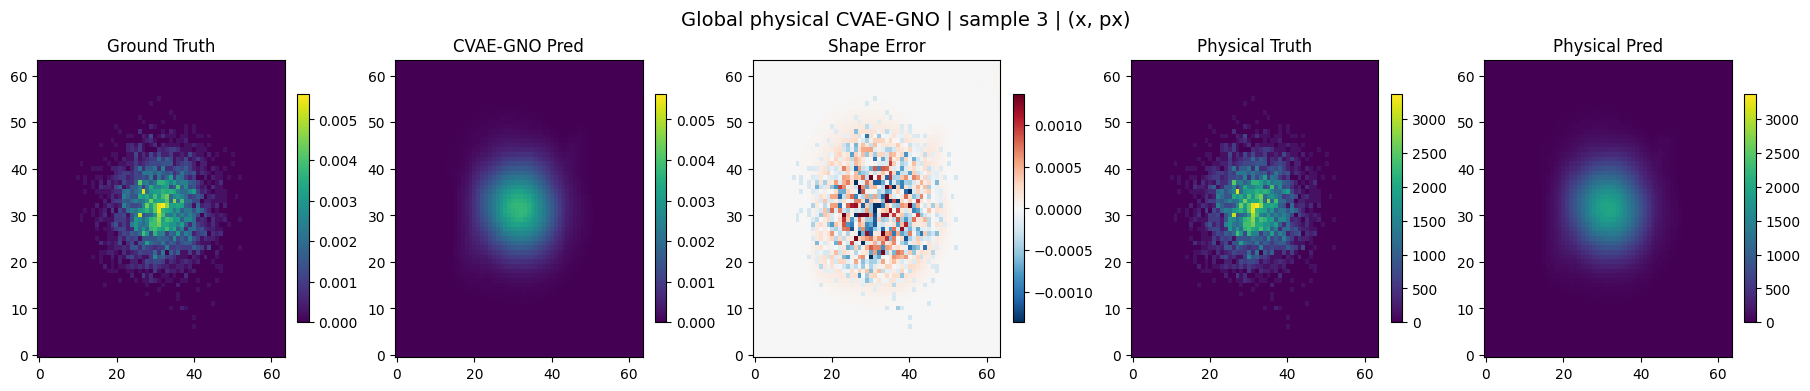

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_shape_triplet_s3_p0_x_px.pdf


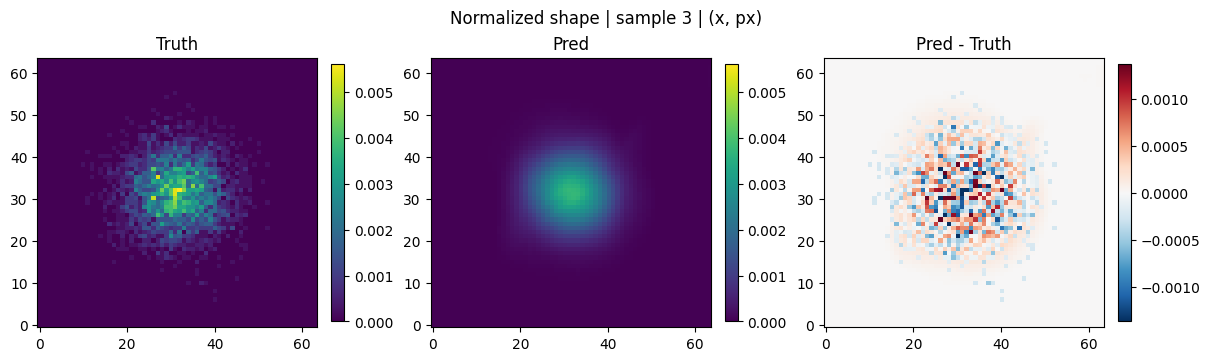

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_physical_5panel_s3_p1_x_y.pdf


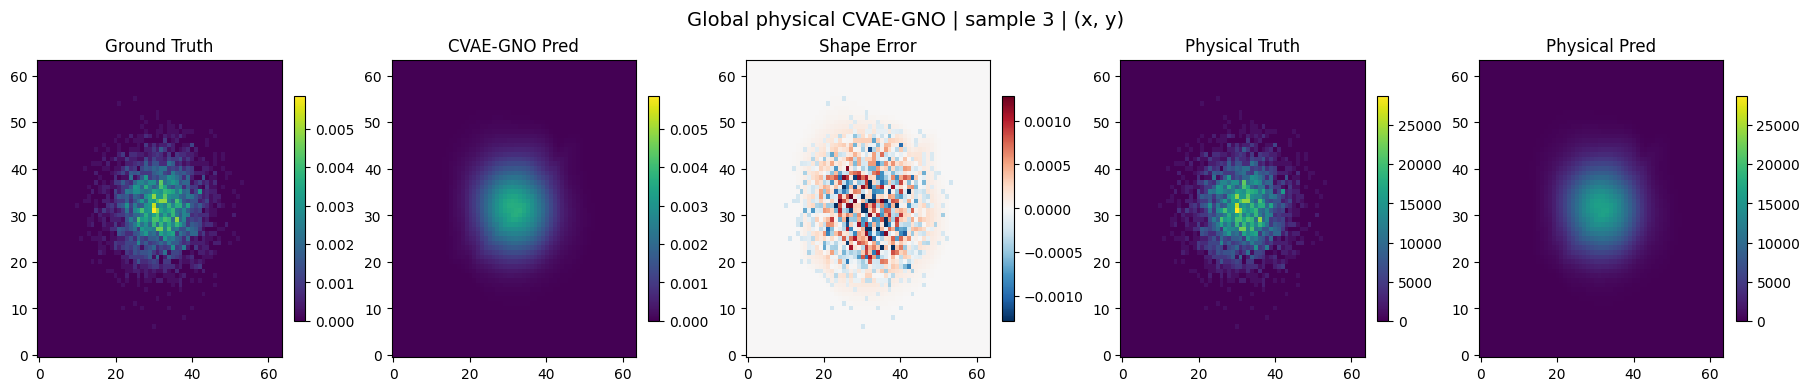

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_shape_triplet_s3_p1_x_y.pdf


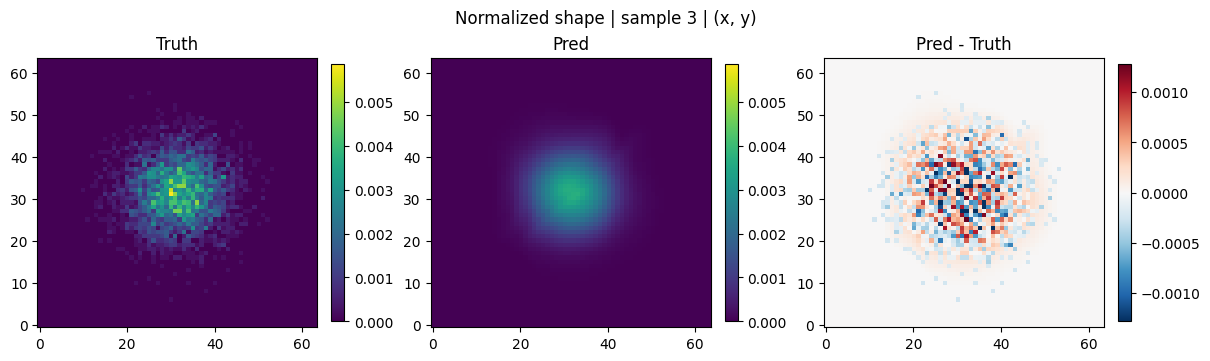

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_physical_5panel_s3_p4_x_delta.pdf


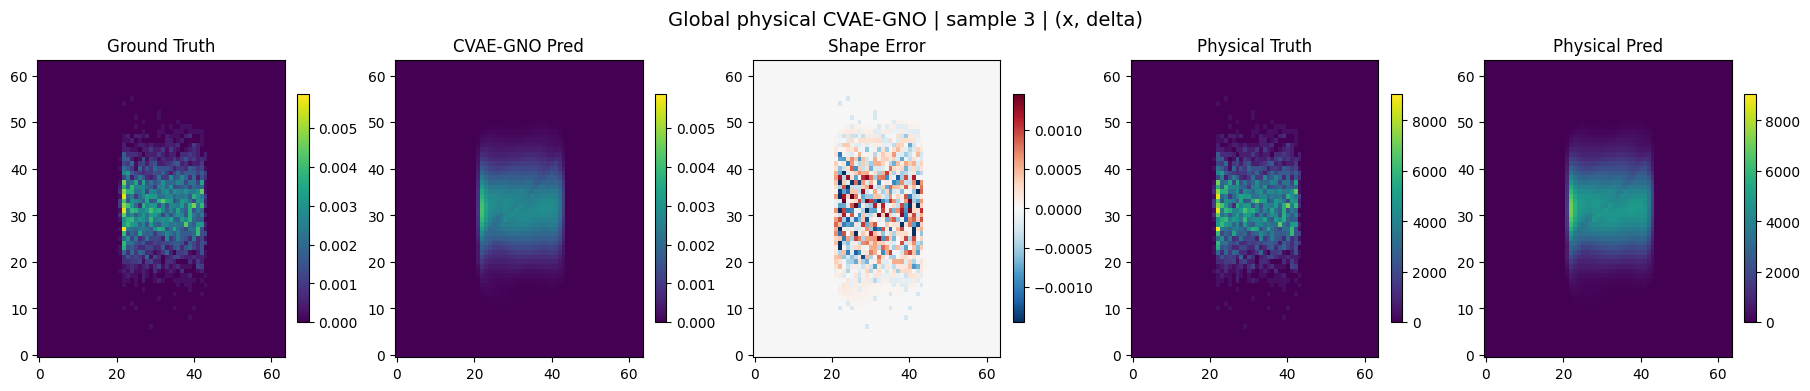

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_shape_triplet_s3_p4_x_delta.pdf


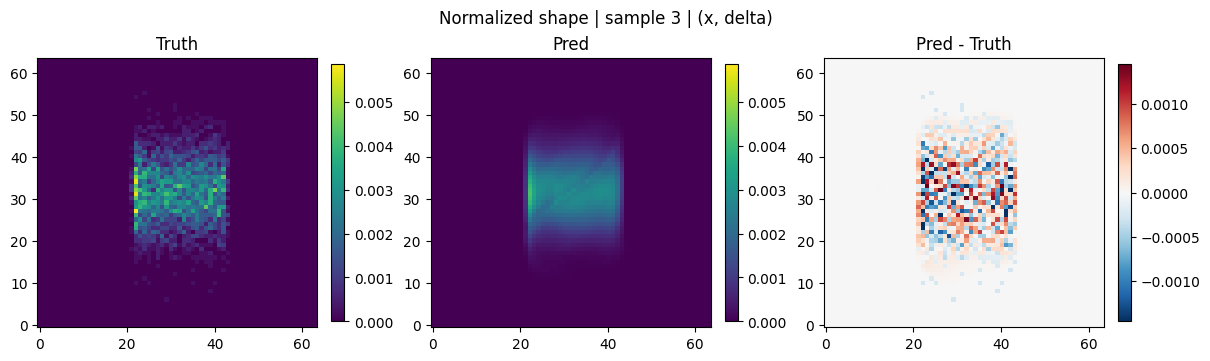

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_physical_5panel_s3_p11_y_delta.pdf


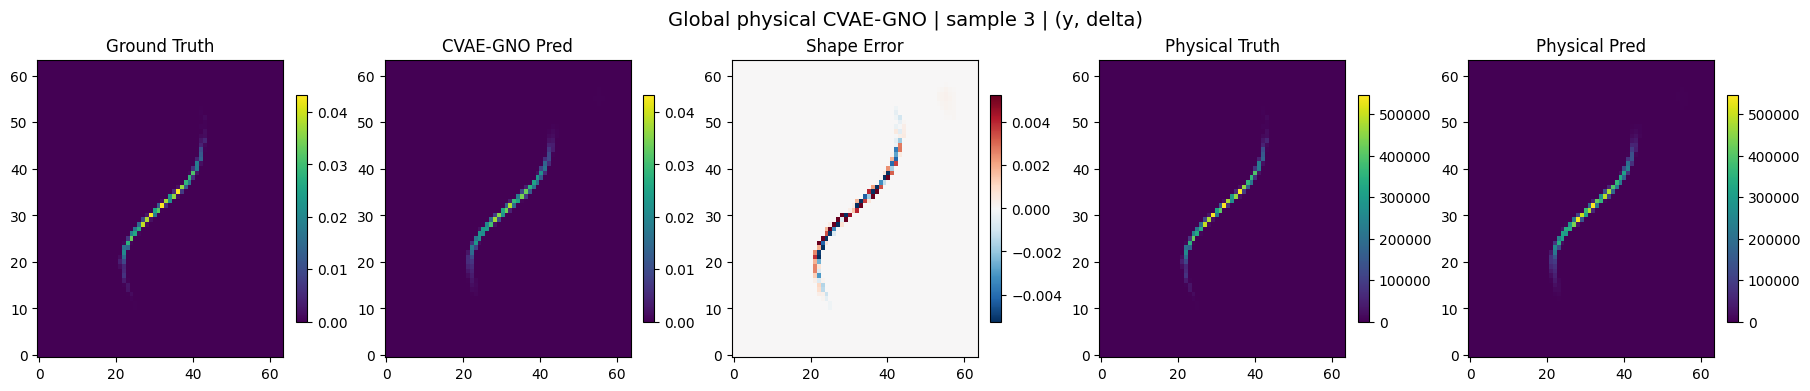

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_shape_triplet_s3_p11_y_delta.pdf


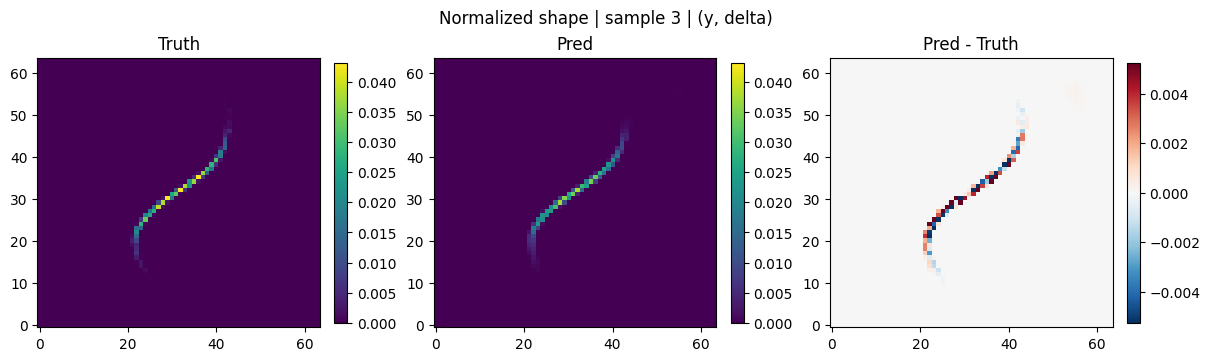

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_sigma_centroid_scatter.pdf


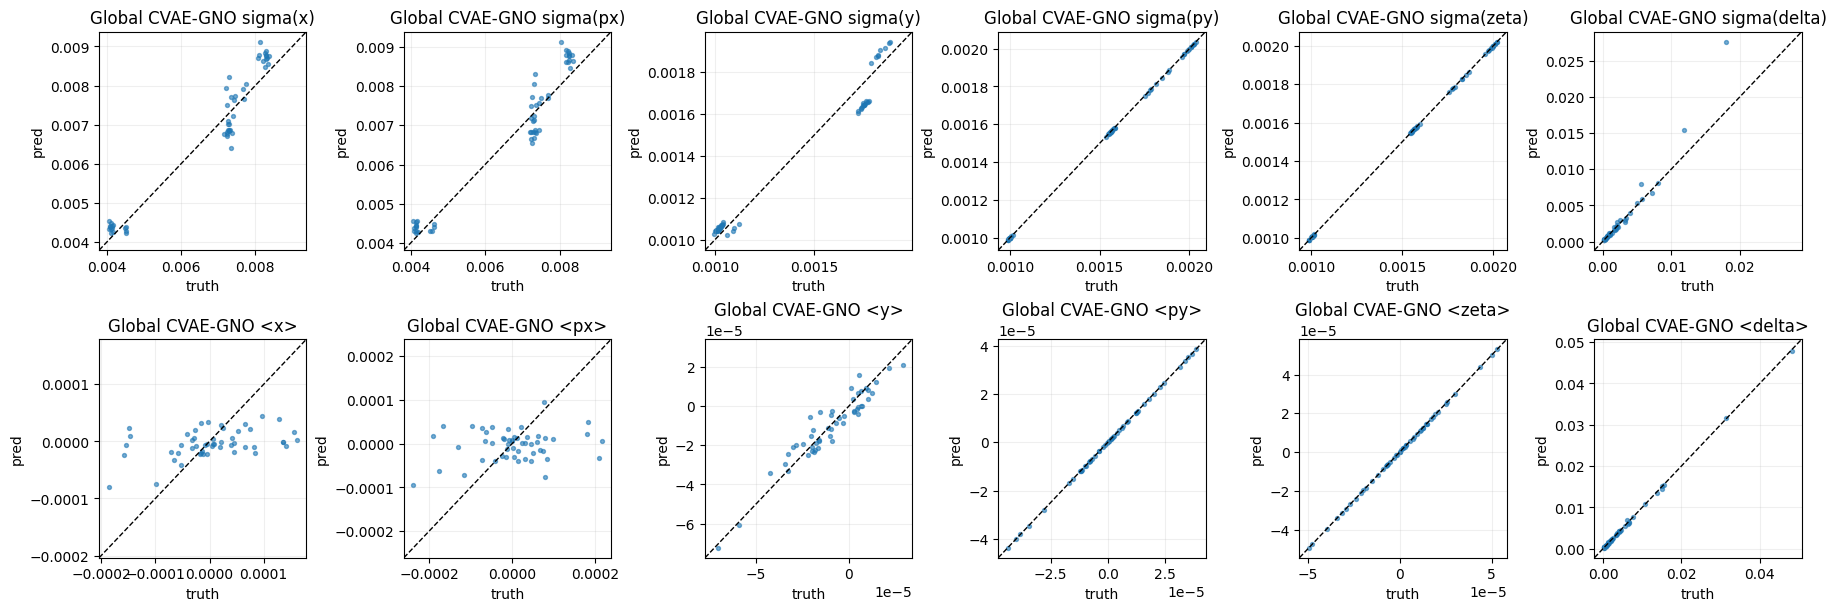

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_sigma_vs_index_x.pdf


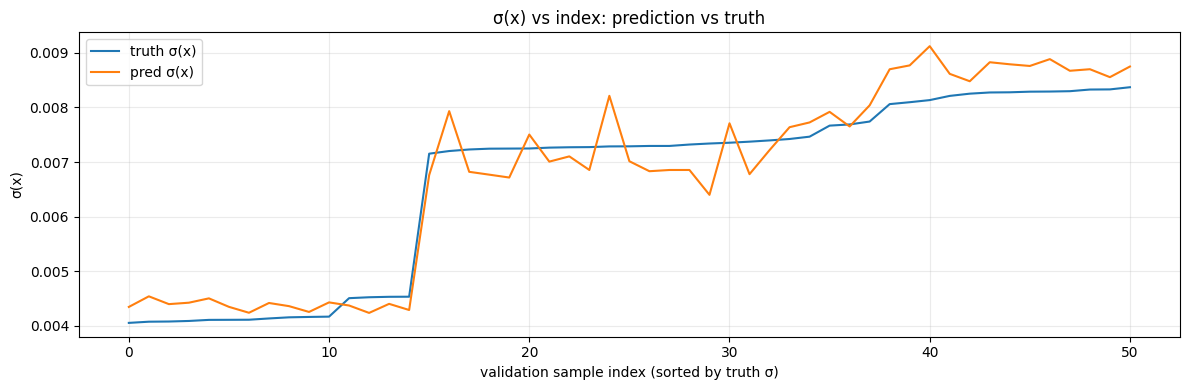

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_sigma_vs_index_px.pdf


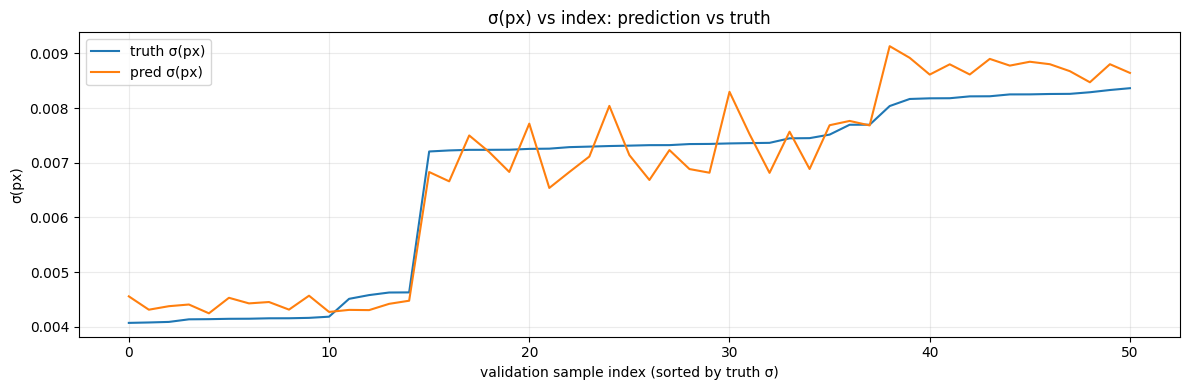

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_sigma_vs_index_y.pdf


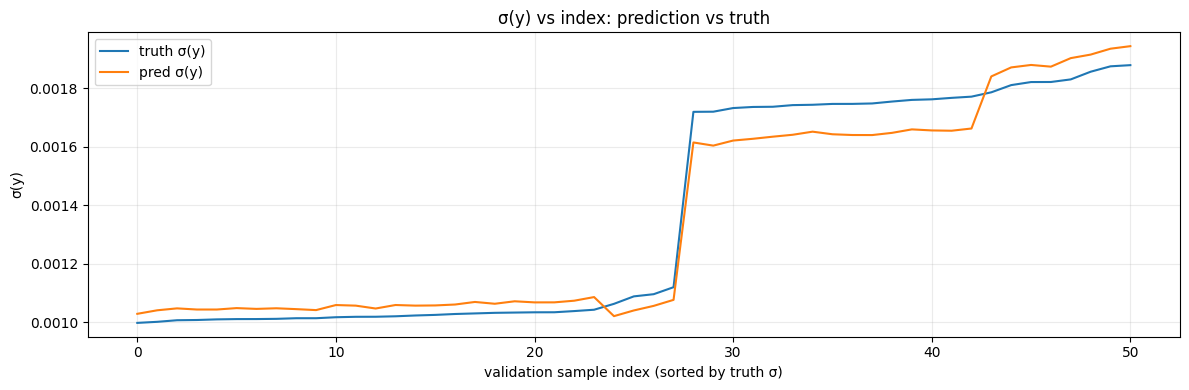

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_sigma_vs_index_py.pdf


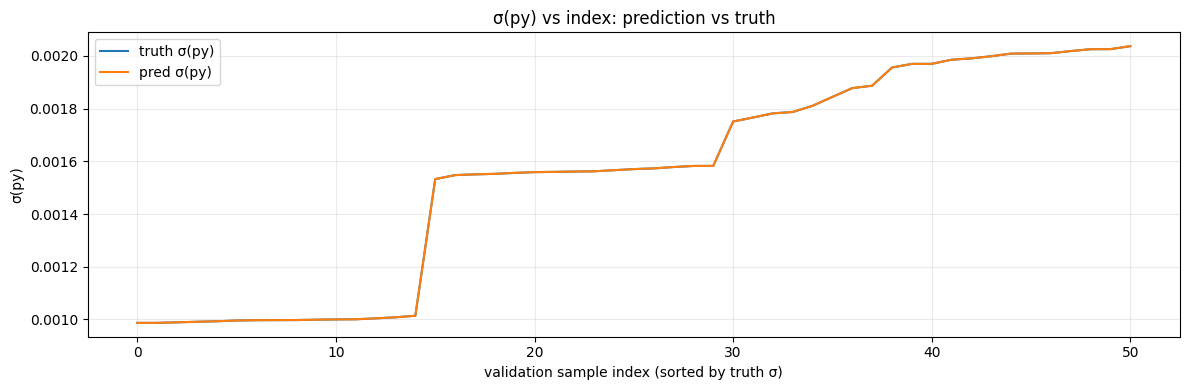

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_sigma_vs_index_zeta.pdf


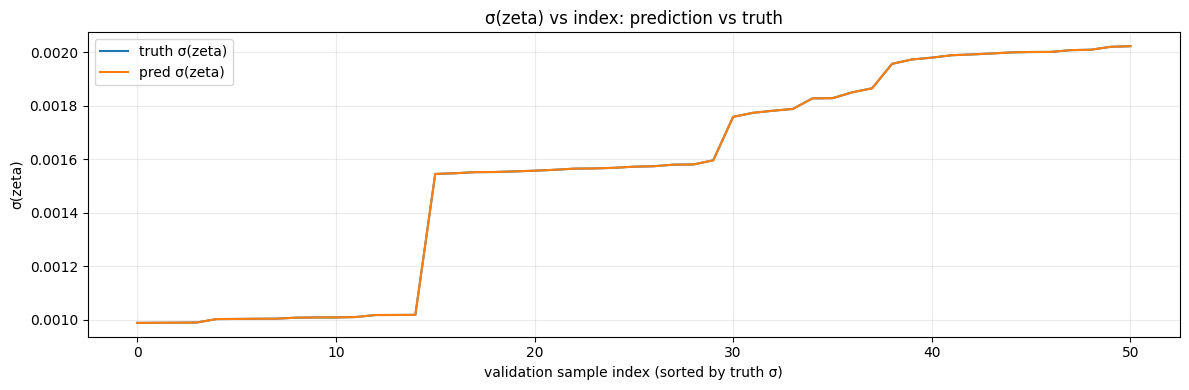

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_sigma_vs_index_delta.pdf


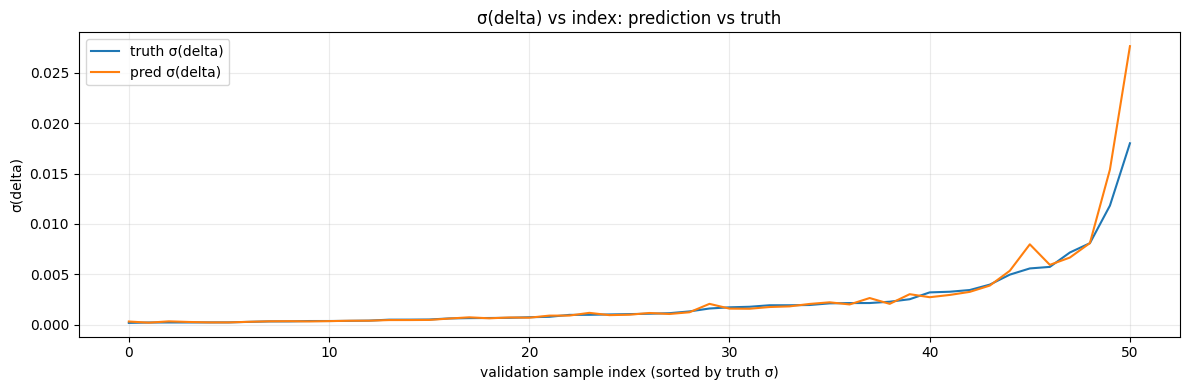

saved: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical/global_macroparticles_s3_p11_y_delta.pdf


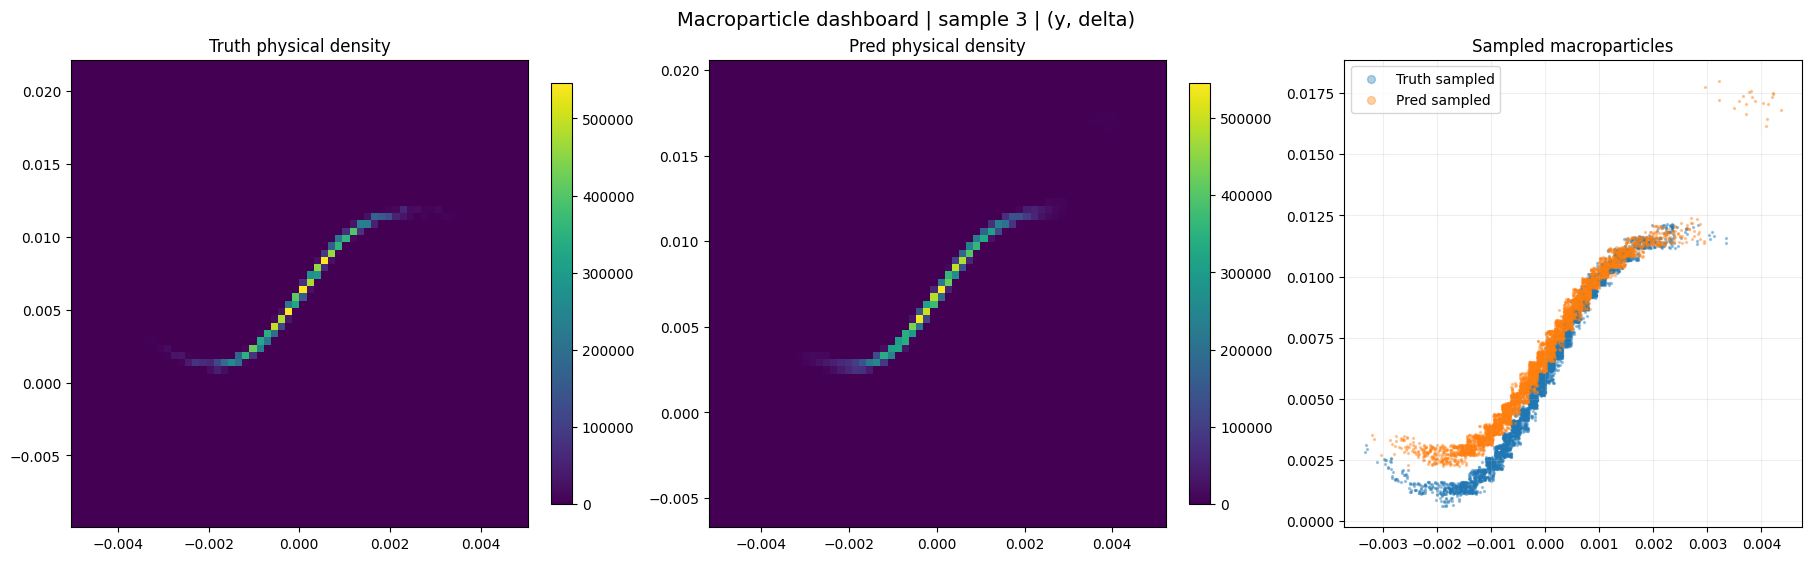


Summary
Global sigma relative error:    1.4996e-01
Global centroid relative error: 2.3831e-02
Figures saved in: /home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical


In [41]:
# ============================================================
# OLD-NOTEBOOK STYLE PLOTS FOR GLOBAL PHYSICAL CVAE+GNO MODEL
# Requires:
#   model, val_loader or test_loader, mu_prep, device
#   model = GlobalPhysicalBeamModel with loaded old CVAE+GNO + trained stats_head
# ============================================================

import os
import re
import numpy as np
import torch
import matplotlib.pyplot as plt

from beam_global_model import *

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
SAVE_DIR = "/home/martinez/ML4CollEffects/reports/final/structured/images/results/global_physical"
os.makedirs(SAVE_DIR, exist_ok=True)

N_elem = 3
LATTICE = "fodo"

SAMPLE_IDX = 3
PAIRS_TO_PLOT = [0, 1, 4, 11]   # x_px, x_y, x_delta, zeta_delta
LONGITUDINAL_PAIR = 11          # zeta_delta

PHASE_SPACE_LABELS = list(COORD_NAMES)

# Use validation loader if available, otherwise test loader
PLOT_LOADER = val_loader if "val_loader" in globals() else test_loader


# ============================================================
# Small helpers
# ============================================================

def to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def sanitize(s):
    s = str(s)
    s = s.replace(r"$", "")
    s = s.replace("\\", "")
    s = s.replace("{", "").replace("}", "")
    s = s.replace("<", "").replace(">", "")
    s = s.replace(" ", "_")
    s = re.sub(r"[^a-zA-Z0-9_]+", "_", s)
    return s.strip("_")

def make_plot_name(sample_idx, pidx, li, lj, tag="comparison", ext="pdf"):
    li = sanitize(li)
    lj = sanitize(lj)
    return f"{tag}_s{sample_idx}_p{pidx}_{li}_{lj}.{ext}"

def make_domain_for_global(MU_raw, model):
    domain_dim = model.distribution.domain_dim
    if MU_raw.shape[1] >= domain_dim:
        return MU_raw[:, :domain_dim]
    return torch.zeros(
        MU_raw.shape[0],
        domain_dim,
        device=MU_raw.device,
        dtype=MU_raw.dtype,
    )

def make_lattice_tokens(B, device, lattice="fodo", N_elem=3):
    if lattice == "fodo":
        return make_fodo_lattice_tokens(B, N_elem, device)
    return make_dummy_lattice_tokens(B, N_elem, device)

@torch.no_grad()
def run_global_batch(model, loader, mu_prep, device, lattice="fodo", N_elem=3):
    model.eval()

    X, Y, MU = next(iter(loader))
    X = X.to(device)
    Y = Y.to(device)
    MU = MU.to(device)

    MU_enc = mu_prep(MU) if mu_prep is not None else MU
    domain = make_domain_for_global(MU, model)
    elem_params, elem_s = make_lattice_tokens(X.shape[0], device, lattice=lattice, N_elem=N_elem)

    out = model(
        X,
        MU_enc,
        elem_params,
        elem_s,
        domain,
        sample_vae=False,
        return_physical_density=True,
    )

    truth_mass = cloud_to_pairwise_hists(
        Y,
        nbins=model.nbins,
        clip_k=model.clip_k,
    )

    centroid_Y, sigma_Y = beam_centroid_sigma(Y)

    truth_density, truth_edges = mass_to_physical_density(
        truth_mass,
        sigma_Y,
        centroid_Y,
        nbins=model.nbins,
        clip_k=model.clip_k,
    )

    return {
        "X": X,
        "Y": Y,
        "MU": MU,
        "out": out,
        "truth_mass": truth_mass,
        "truth_density": truth_density,
        "truth_edges": truth_edges,
        "sigma_true": sigma_Y,
        "centroid_true": centroid_Y,
        "sigma_pred": out["sigmaN_hat"],
        "centroid_pred": out["centroidN_hat"],
    }


batch = run_global_batch(
    model,
    PLOT_LOADER,
    mu_prep,
    device,
    lattice=LATTICE,
    N_elem=N_elem,
)

SAMPLE_IDX = min(SAMPLE_IDX, batch["Y"].shape[0] - 1)


# ============================================================
# 1. Old triplet plot: truth / pred / residual
# ============================================================

def plot_hist_triplet(truth_map, pred_map, title="", filename=None, log=False):
    truth_map = np.asarray(truth_map)
    pred_map = np.asarray(pred_map)

    diff = pred_map - truth_map

    if log:
        eps = 1e-12
        truth_show = np.log10(truth_map + eps)
        pred_show = np.log10(pred_map + eps)
        t0 = "Truth log10"
        t1 = "Pred log10"
        vmin = None
        vmax = None
    else:
        truth_show = truth_map
        pred_show = pred_map
        t0 = "Truth"
        t1 = "Pred"
        vmin = 0.0
        vmax = float(max(truth_map.max(), pred_map.max()) + 1e-12)

    dv = float(np.percentile(np.abs(diff), 99.5) + 1e-12)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)

    im0 = axes[0].imshow(
        truth_show,
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",
    )
    axes[0].set_title(t0)
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(
        pred_show,
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        cmap="viridis",
    )
    axes[1].set_title(t1)
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(
        diff,
        origin="lower",
        aspect="auto",
        vmin=-dv,
        vmax=dv,
        cmap="RdBu_r",
    )
    axes[2].set_title("Pred - Truth")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    fig.suptitle(title)

    if filename is not None:
        fig.savefig(filename, bbox_inches="tight", dpi=220)
        print("saved:", filename)

    plt.show()
    return fig


# ============================================================
# 2. Old 5-panel style adapted to single global physical model
#    mass truth / mass pred / mass residual / density truth / density pred
# ============================================================

def plot_5_panel_global_physical(
    truth_mass,
    pred_mass,
    truth_density,
    pred_density,
    title="",
    filename=None,
):
    truth_mass = np.asarray(truth_mass)
    pred_mass = np.asarray(pred_mass)
    truth_density = np.asarray(truth_density)
    pred_density = np.asarray(pred_density)

    diff_mass = pred_mass - truth_mass

    vmax_mass = float(max(truth_mass.max(), pred_mass.max()) + 1e-12)
    max_err = float(np.percentile(np.abs(diff_mass), 99.5) + 1e-12)

    vmax_density = float(max(truth_density.max(), pred_density.max()) + 1e-12)

    fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), constrained_layout=True)

    im0 = axes[0].imshow(
        truth_mass,
        origin="lower",
        aspect="auto",
        vmin=0,
        vmax=vmax_mass,
        cmap="viridis",
    )
    axes[0].set_title("Ground Truth")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(
        pred_mass,
        origin="lower",
        aspect="auto",
        vmin=0,
        vmax=vmax_mass,
        cmap="viridis",
    )
    axes[1].set_title("CVAE-GNO Pred")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(
        diff_mass,
        origin="lower",
        aspect="auto",
        vmin=-max_err,
        vmax=max_err,
        cmap="RdBu_r",
    )
    axes[2].set_title("Shape Error")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    im3 = axes[3].imshow(
        truth_density,
        origin="lower",
        aspect="auto",
        vmin=0,
        vmax=vmax_density,
        cmap="viridis",
    )
    axes[3].set_title("Physical Truth")
    plt.colorbar(im3, ax=axes[3], fraction=0.046)

    im4 = axes[4].imshow(
        pred_density,
        origin="lower",
        aspect="auto",
        vmin=0,
        vmax=vmax_density,
        cmap="viridis",
    )
    axes[4].set_title("Physical Pred")
    plt.colorbar(im4, ax=axes[4], fraction=0.046)

    fig.suptitle(title, fontsize=14)

    if filename is not None:
        fig.savefig(filename, bbox_inches="tight", dpi=220)
        print("saved:", filename)

    plt.show()
    return fig


# ============================================================
# 3. Sigma / centroid scatter, old notebook style
# ============================================================

def plot_sigma_centroid_scatter(
    sigma_true,
    sigma_pred,
    cent_true,
    cent_pred,
    title_prefix="Global CVAE-GNO",
    filename=None,
):
    sigma_true = np.asarray(sigma_true)
    sigma_pred = np.asarray(sigma_pred)
    cent_true = np.asarray(cent_true)
    cent_pred = np.asarray(cent_pred)

    fig, axes = plt.subplots(2, 6, figsize=(18, 6), constrained_layout=True)

    for d in range(6):
        ax = axes[0, d]
        x = sigma_true[:, d]
        y = sigma_pred[:, d]

        ax.scatter(x, y, s=8, alpha=0.6)
        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        pad = 0.05 * (hi - lo + 1e-15)

        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_title(f"{title_prefix} sigma({PHASE_SPACE_LABELS[d]})")
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")
        ax.grid(alpha=0.2)

    for d in range(6):
        ax = axes[1, d]
        x = cent_true[:, d]
        y = cent_pred[:, d]

        ax.scatter(x, y, s=8, alpha=0.6)
        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        pad = 0.05 * (hi - lo + 1e-15)

        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_title(f"{title_prefix} <{PHASE_SPACE_LABELS[d]}>")
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")
        ax.grid(alpha=0.2)

    if filename is not None:
        fig.savefig(filename, bbox_inches="tight", dpi=220)
        print("saved:", filename)

    plt.show()
    return fig


# ============================================================
# 4. Collect sigma/centroid over validation/test set
# ============================================================

@torch.no_grad()
def collect_sigma_centroid_over_loader(
    model,
    loader,
    mu_prep,
    device,
    lattice="fodo",
    N_elem=3,
    max_batches=None,
):
    model.eval()

    sigma_true_all = []
    sigma_pred_all = []
    cent_true_all = []
    cent_pred_all = []

    for ib, (X, Y, MU) in enumerate(loader):
        if max_batches is not None and ib >= max_batches:
            break

        X = X.to(device)
        Y = Y.to(device)
        MU = MU.to(device)

        MU_enc = mu_prep(MU) if mu_prep is not None else MU
        domain = make_domain_for_global(MU, model)
        elem_params, elem_s = make_lattice_tokens(X.shape[0], device, lattice=lattice, N_elem=N_elem)

        out = model(
            X,
            MU_enc,
            elem_params,
            elem_s,
            domain,
            sample_vae=False,
            return_physical_density=False,
        )

        cent_Y, sig_Y = beam_centroid_sigma(Y)

        sigma_true_all.append(to_np(sig_Y))
        sigma_pred_all.append(to_np(out["sigmaN_hat"]))
        cent_true_all.append(to_np(cent_Y))
        cent_pred_all.append(to_np(out["centroidN_hat"]))

    return (
        np.concatenate(sigma_true_all, axis=0),
        np.concatenate(sigma_pred_all, axis=0),
        np.concatenate(cent_true_all, axis=0),
        np.concatenate(cent_pred_all, axis=0),
    )


sigma_true_all, sigma_pred_all, cent_true_all, cent_pred_all = collect_sigma_centroid_over_loader(
    model,
    PLOT_LOADER,
    mu_prep,
    device,
    lattice=LATTICE,
    N_elem=N_elem,
    max_batches=None,
)


# ============================================================
# 5. Sigma vs index, old notebook style
# ============================================================

def plot_sigma_vs_index(
    sigma_true_all,
    sigma_pred_all,
    coord=0,
    sort_by_truth=True,
    filename=None,
):
    sigma_true_all = np.asarray(sigma_true_all)
    sigma_pred_all = np.asarray(sigma_pred_all)

    y_true = sigma_true_all[:, coord]
    y_pred = sigma_pred_all[:, coord]

    if sort_by_truth:
        order = np.argsort(y_true)
        y_true = y_true[order]
        y_pred = y_pred[order]

    x = np.arange(len(y_true))

    fig = plt.figure(figsize=(12, 4))
    plt.plot(
        x,
        y_true,
        lw=1.5,
        color="tab:blue",
        label=f"truth σ({PHASE_SPACE_LABELS[coord]})",
    )
    plt.plot(
        x,
        y_pred,
        lw=1.5,
        color="tab:orange",
        label=f"pred σ({PHASE_SPACE_LABELS[coord]})",
    )
    plt.xlabel("validation sample index" + (" (sorted by truth σ)" if sort_by_truth else ""))
    plt.ylabel(f"σ({PHASE_SPACE_LABELS[coord]})")
    plt.title(f"σ({PHASE_SPACE_LABELS[coord]}) vs index: prediction vs truth")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        fig.savefig(filename, bbox_inches="tight", dpi=220)
        print("saved:", filename)

    plt.show()
    return fig


# ============================================================
# 6. Macroparticle sampling plots, old notebook style
# ============================================================

def sample_macroparticles_2d_from_density(
    density,
    x_edges=None,
    y_edges=None,
    num_particles=100_000,
    seed=0,
):
    rng = np.random.default_rng(seed)

    density = np.asarray(density, dtype=np.float64)
    density = np.maximum(density, 0.0)

    if density.sum() <= 0:
        density = np.ones_like(density)

    prob = density.ravel()
    prob = prob / prob.sum()

    nx, ny = density.shape
    inds = rng.choice(nx * ny, size=num_particles, replace=True, p=prob)
    ix = inds // ny
    iy = inds % ny

    if x_edges is None:
        x_edges = np.arange(nx + 1)
    if y_edges is None:
        y_edges = np.arange(ny + 1)

    x_edges = np.asarray(x_edges)
    y_edges = np.asarray(y_edges)

    # Uniform inside selected bin
    u = rng.random(num_particles)
    v = rng.random(num_particles)

    xs = x_edges[ix] + u * (x_edges[ix + 1] - x_edges[ix])
    ys = y_edges[iy] + v * (y_edges[iy + 1] - y_edges[iy])

    return xs, ys

def plot_distribution_and_sampled_macroparticles(
    density,
    x_edges=None,
    y_edges=None,
    title="Phase Space View",
    num_particles=100_000,
    plot_stride=10,
    cmap="viridis",
    filename=None,
):
    x_p, y_p = sample_macroparticles_2d_from_density(
        density,
        x_edges=x_edges,
        y_edges=y_edges,
        num_particles=num_particles,
        seed=42,
    )

    x_plot = x_p[::plot_stride]
    y_plot = y_p[::plot_stride]

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

    if x_edges is None or y_edges is None:
        mesh0 = ax0.imshow(
            density.T,
            origin="lower",
            cmap=cmap,
            aspect="auto",
            interpolation="nearest",
        )
    else:
        mesh0 = ax0.pcolormesh(
            x_edges,
            y_edges,
            density.T,
            cmap=cmap,
            shading="auto",
        )

    ax0.set_title("Density Distribution")
    plt.colorbar(mesh0, ax=ax0, fraction=0.046)

    ax1.scatter(x_plot, y_plot, s=1, alpha=0.35)
    ax1.set_title(f"Sampled macroparticles, N={num_particles:,}")
    ax1.grid(alpha=0.2)

    fig.suptitle(title, fontsize=14)

    if filename is not None:
        fig.savefig(filename, bbox_inches="tight", dpi=220)
        print("saved:", filename)

    plt.show()
    return fig

def plot_global_macroparticle_dashboard(
    truth_density,
    pred_density,
    truth_x_edges,
    truth_y_edges,
    pred_x_edges,
    pred_y_edges,
    pair_label="",
    num_particles=200_000,
    plot_stride=50,
    filename=None,
):
    truth_density = np.asarray(truth_density)
    pred_density = np.asarray(pred_density)

    xt, yt = sample_macroparticles_2d_from_density(
        truth_density,
        x_edges=truth_x_edges,
        y_edges=truth_y_edges,
        num_particles=num_particles,
        seed=123,
    )

    xp, yp = sample_macroparticles_2d_from_density(
        pred_density,
        x_edges=pred_x_edges,
        y_edges=pred_y_edges,
        num_particles=num_particles,
        seed=456,
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

    im0 = axes[0].pcolormesh(
        truth_x_edges,
        truth_y_edges,
        truth_density.T,
        shading="auto",
        cmap="viridis",
    )
    axes[0].set_title("Truth physical density")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].pcolormesh(
        pred_x_edges,
        pred_y_edges,
        pred_density.T,
        shading="auto",
        cmap="viridis",
    )
    axes[1].set_title("Pred physical density")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    axes[2].scatter(
        xt[::plot_stride],
        yt[::plot_stride],
        s=2,
        alpha=0.35,
        label="Truth sampled",
    )
    axes[2].scatter(
        xp[::plot_stride],
        yp[::plot_stride],
        s=2,
        alpha=0.35,
        label="Pred sampled",
    )
    axes[2].set_title("Sampled macroparticles")
    axes[2].grid(alpha=0.2)
    axes[2].legend(markerscale=4)

    fig.suptitle(f"Macroparticle dashboard | {pair_label}", fontsize=14)

    if filename is not None:
        fig.savefig(filename, bbox_inches="tight", dpi=220)
        print("saved:", filename)

    plt.show()
    return fig


# ============================================================
# RUN ALL PLOTS
# ============================================================

truth_mass = batch["truth_mass"]
pred_mass = batch["out"]["histN_mass"]

truth_density = batch["truth_density"]
pred_density = batch["out"]["histN_density"]

truth_edges = batch["truth_edges"]
pred_x_edges = batch["out"]["pair_x_edges"]
pred_y_edges = batch["out"]["pair_y_edges"]

# ------------------------------------------------------------
# A. Pairwise comparison plots
# ------------------------------------------------------------
for pidx in PAIRS_TO_PLOT:
    i, j = PAIR_INDEX[pidx]
    li = PHASE_SPACE_LABELS[i]
    lj = PHASE_SPACE_LABELS[j]

    tm = to_np(truth_mass[SAMPLE_IDX, pidx])
    pm = to_np(pred_mass[SAMPLE_IDX, pidx])

    td = to_np(truth_density[SAMPLE_IDX, pidx])
    pd = to_np(pred_density[SAMPLE_IDX, pidx])

    fname_5 = os.path.join(
        SAVE_DIR,
        make_plot_name(SAMPLE_IDX, pidx, li, lj, tag="global_physical_5panel", ext="pdf"),
    )

    plot_5_panel_global_physical(
        tm,
        pm,
        td,
        pd,
        title=f"Global physical CVAE-GNO | sample {SAMPLE_IDX} | ({li}, {lj})",
        filename=fname_5,
    )

    fname_triplet = os.path.join(
        SAVE_DIR,
        make_plot_name(SAMPLE_IDX, pidx, li, lj, tag="global_shape_triplet", ext="pdf"),
    )

    plot_hist_triplet(
        tm,
        pm,
        title=f"Normalized shape | sample {SAMPLE_IDX} | ({li}, {lj})",
        filename=fname_triplet,
        log=False,
    )

# ------------------------------------------------------------
# B. Sigma and centroid parity
# ------------------------------------------------------------
plot_sigma_centroid_scatter(
    sigma_true_all,
    sigma_pred_all,
    cent_true_all,
    cent_pred_all,
    title_prefix="Global CVAE-GNO",
    filename=os.path.join(SAVE_DIR, "global_sigma_centroid_scatter.pdf"),
)

# ------------------------------------------------------------
# C. Sigma vs index plots for all six coordinates
# ------------------------------------------------------------
for coord in range(6):
    plot_sigma_vs_index(
        sigma_true_all,
        sigma_pred_all,
        coord=coord,
        sort_by_truth=True,
        filename=os.path.join(
            SAVE_DIR,
            f"global_sigma_vs_index_{sanitize(PHASE_SPACE_LABELS[coord])}.pdf",
        ),
    )

# ------------------------------------------------------------
# D. Longitudinal macroparticle dashboard
# ------------------------------------------------------------
pidx = LONGITUDINAL_PAIR
i, j = PAIR_INDEX[pidx]
li = PHASE_SPACE_LABELS[i]
lj = PHASE_SPACE_LABELS[j]

plot_global_macroparticle_dashboard(
    truth_density=to_np(truth_density[SAMPLE_IDX, pidx]),
    pred_density=to_np(pred_density[SAMPLE_IDX, pidx]),
    truth_x_edges=to_np(truth_edges["pair_x_edges"][SAMPLE_IDX, pidx]),
    truth_y_edges=to_np(truth_edges["pair_y_edges"][SAMPLE_IDX, pidx]),
    pred_x_edges=to_np(pred_x_edges[SAMPLE_IDX, pidx]),
    pred_y_edges=to_np(pred_y_edges[SAMPLE_IDX, pidx]),
    pair_label=f"sample {SAMPLE_IDX} | ({li}, {lj})",
    num_particles=200_000,
    plot_stride=50,
    filename=os.path.join(
        SAVE_DIR,
        make_plot_name(SAMPLE_IDX, pidx, li, lj, tag="global_macroparticles", ext="pdf"),
    ),
)

# ------------------------------------------------------------
# E. Compact numeric summary
# ------------------------------------------------------------
sigma_rel = np.linalg.norm(sigma_pred_all - sigma_true_all) / (np.linalg.norm(sigma_true_all) + 1e-12)
cent_rel = np.linalg.norm(cent_pred_all - cent_true_all) / (np.linalg.norm(cent_true_all) + 1e-12)

print("\nSummary")
print("=======")
print(f"Global sigma relative error:    {sigma_rel:.4e}")
print(f"Global centroid relative error: {cent_rel:.4e}")
print(f"Figures saved in: {SAVE_DIR}")

batch 000 | B=16 | MC=64 | mass mean var=6.020e-11 | density mean var=3.698e+05
batch 001 | B=16 | MC=64 | mass mean var=7.040e-11 | density mean var=4.208e+05
batch 002 | B=16 | MC=64 | mass mean var=9.381e-11 | density mean var=9.469e+05
batch 003 | B=3 | MC=64 | mass mean var=6.523e-11 | density mean var=1.467e+05

Done computing global physical uncertainty.


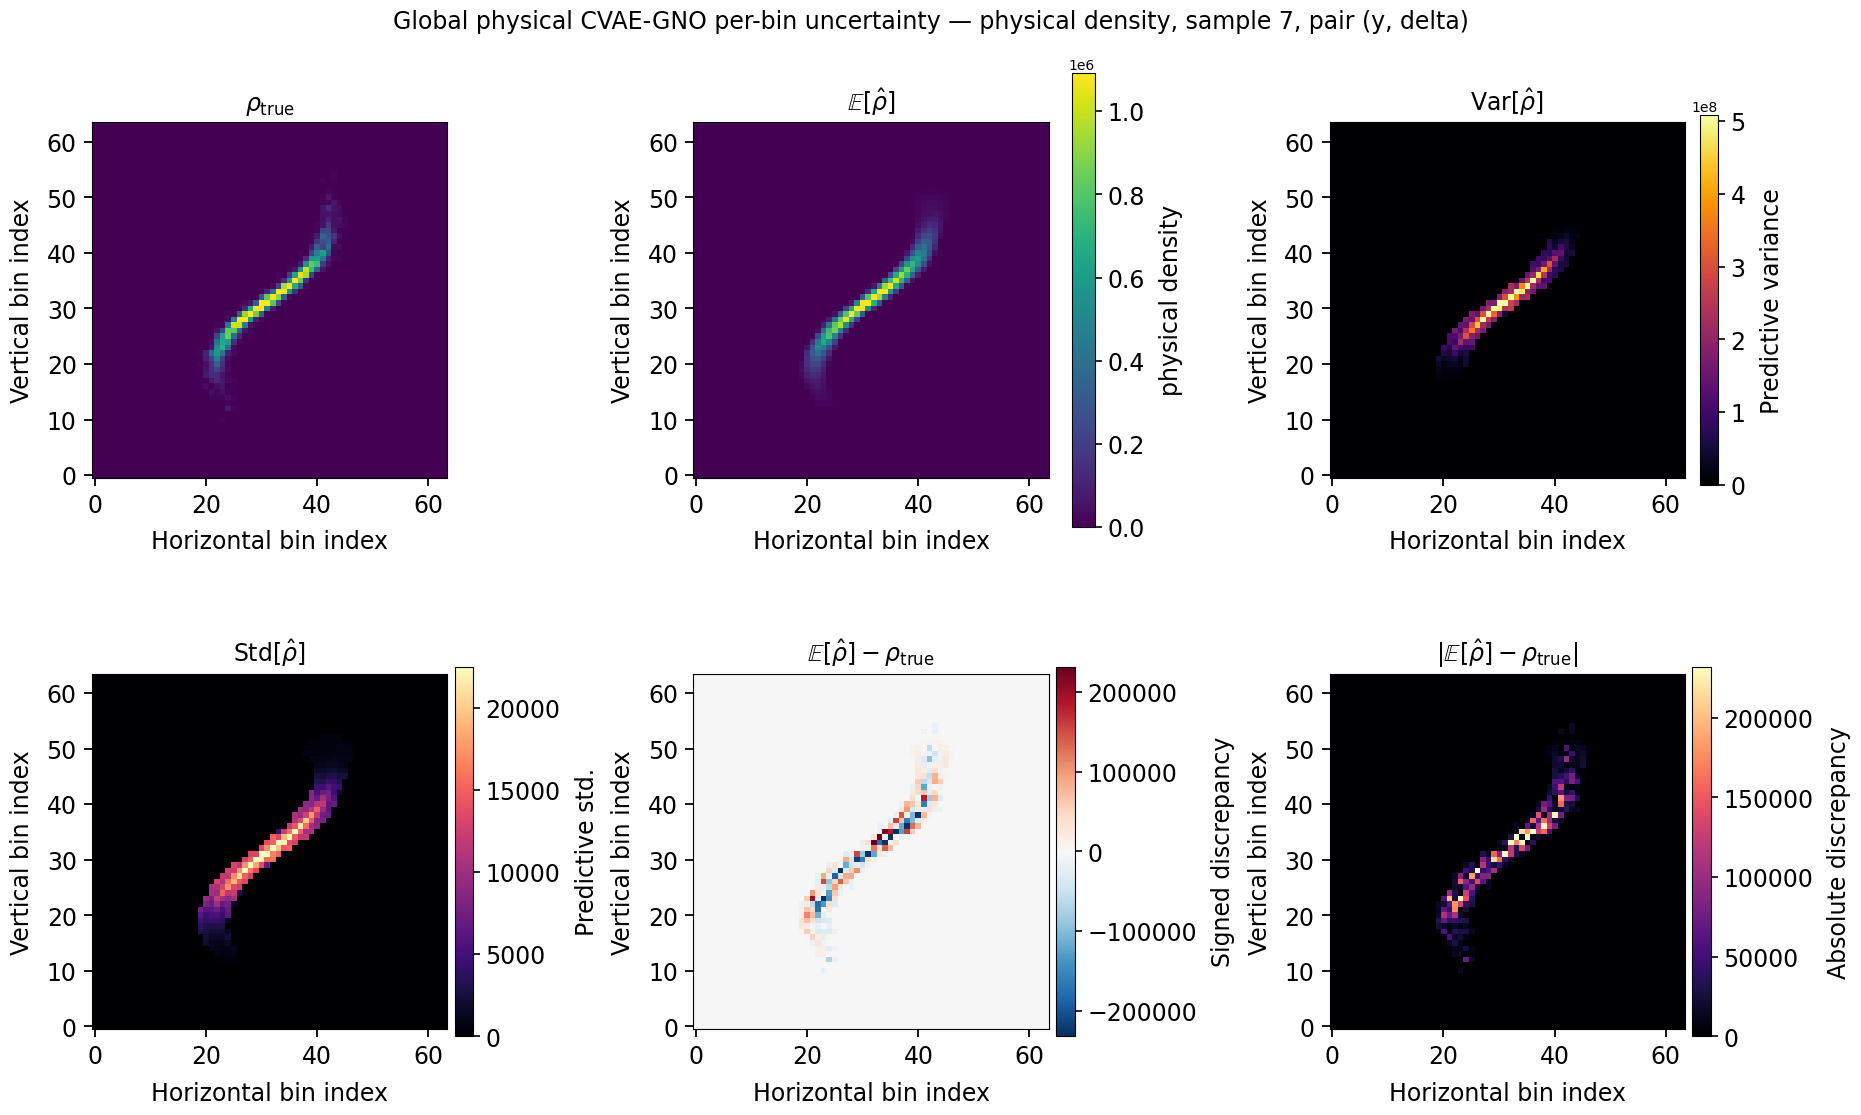


GLOBAL PHYSICAL CVAE-GNO PER-BIN UNCERTAINTY
Target:                density
Physical sample index: 7
Histogram pair index:  11
Histogram pair:        (y, delta)

Per-bin predictive variance:
  mean = 6.283836e+06
  max  = 6.878963e+08
  sum  = 2.573859e+10

Per-bin predictive standard deviation:
  mean = 4.686791e+02
  max  = 2.622778e+04

Signed ensemble-mean discrepancy:
  mean = -2.059889e+02
  min  = -5.727418e+05
  max  = 2.591609e+05

Absolute ensemble-mean discrepancy:
  mean = 3.487909e+03
  max  = 5.727418e+05

Saved figure:
/home/martinez/ML4CollEffects/reports/final/structured/images/results/png/global_physical_per_bin_uncertainty_density_s7_p11_y_delta.png

Saved per-bin CSV:
/home/martinez/ML4CollEffects/reports/final/structured/images/results/png/global_physical_per_bin_uncertainty_density_s7_p11_y_delta.csv

Top 20 highest-variance histogram bins:


,sample_idx,pair_idx,target,bin_i,bin_j,rho_true,rho_mean,rho_variance,rho_std,mean_minus_truth,abs_mean_minus_truth
2080,7,11,density,32,32,1.100649e+06,1.218514e+06,687896320.0,26227.777344,117864.7500,117864.7500
1884,7,11,density,29,28,1.222943e+06,1.178862e+06,654264832.0,25578.601562,-44081.5000,44081.5000
1949,7,11,density,30,29,1.406390e+06,1.190627e+06,631156544.0,25122.830078,-215762.3750,215762.3750
2015,7,11,density,31,31,1.742694e+06,1.169952e+06,619515968.0,24890.078125,-572741.7500,572741.7500
2211,7,11,density,34,35,1.360524e+06,1.077057e+06,569145472.0,23856.769531,-283467.2500,283467.2500
2145,7,11,density,33,33,1.299378e+06,1.126199e+06,558371072.0,23629.876953,-173179.2500,173179.2500
2276,7,11,density,35,36,1.329951e+06,1.021892e+06,547372224.0,23395.988281,-308058.7500,308058.7500
1819,7,11,density,28,27,1.100649e+06,1.060156e+06,532344256.0,23072.585938,-40493.0000,40493.0000
2014,7,11,density,31,30,1.161797e+06,1.076401e+06,513209664.0,22654.130859,-85396.0000,85396.0000
1950,7,11,density,30,30,1.222944e+06,1.061519e+06,486301216.0,22052.238281,-161425.2500,161425.2500


In [ ]:
# ============================================================
# GLOBAL PHYSICAL CVAE+GNO UNCERTAINTY
# Dataset-wide MC cell + per-bin six-panel plot
#
# For the new model:
#   model = GlobalPhysicalBeamModel(...)
#
# It computes uncertainty for:
#   1) normalized pairwise histogram mass
#   2) physical pairwise density after predicted sigma/centroid scaling
#
# Requires:
#   model, test_loader or val_loader, mu_prep, device
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from beam_global_model import *

# ============================================================
# 1. USER CONFIGURATION
# ============================================================

PLOT_LOADER = test_loader if "test_loader" in globals() else val_loader

SAVE_DIR = (
    "/home/martinez/ML4CollEffects/reports/final/"
    "structured/images/results/png"
)
os.makedirs(SAVE_DIR, exist_ok=True)

N_MC = 64                  # number of stochastic forward passes
N_ELEM = 3
LATTICE = "fodo"

SELECTED_SAMPLE_IDX = 7
SELECTED_PAIR_IDX = 11     # usually (zeta, delta)

# Choose:
#   "mass"    -> normalized pairwise histograms
#   "density" -> physical densities after predicted sigma/centroid units
UNCERTAINTY_TARGET = "density"

PHASE_SPACE_LABELS = list(COORD_NAMES)

AXIS_LABEL_SIZE = 17
TICK_LABEL_SIZE = 17
TITLE_SIZE = 17
COLORBAR_LABEL_SIZE = 17
COLORBAR_TICK_SIZE = 17
SUPTITLE_SIZE = 17


# ============================================================
# 2. HELPERS
# ============================================================

def to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def sanitize_filename(s):
    s = str(s)
    s = s.replace(" ", "")
    s = s.replace("/", "-")
    s = s.replace("\\", "")
    s = s.replace("$", "")
    s = s.replace("{", "")
    s = s.replace("}", "")
    s = re.sub(r"[^a-zA-Z0-9_\-]+", "_", s)
    return s.strip("_")

def make_domain_from_mu(MU, model):
    domain_dim = model.distribution.domain_dim
    if MU.shape[1] >= domain_dim:
        return MU[:, :domain_dim]
    return torch.zeros(
        MU.shape[0],
        domain_dim,
        device=MU.device,
        dtype=MU.dtype,
    )

def make_tokens(B, device, lattice="fodo", N_elem=3):
    if lattice == "fodo":
        return make_fodo_lattice_tokens(B, N_elem, device)
    return make_dummy_lattice_tokens(B, N_elem, device)


# ============================================================
# 3. DATASET-WIDE MC UNCERTAINTY FOR GLOBAL MODEL
# ============================================================

@torch.no_grad()
def compute_global_physical_uncertainty(
    model,
    loader,
    mu_prep,
    device,
    n_mc=64,
    n_elem=3,
    lattice="fodo",
    max_batches=None,
):
    """
    Repeated full global-model forward passes.

    Returns:
      hist_mass_mean, hist_mass_var, hist_mass_std, hist_mass_truth
      density_mean, density_var, density_std, density_truth
      sigma_mean, sigma_var, sigma_truth
      centroid_mean, centroid_var, centroid_truth
    """

    model.eval()

    hist_mass_mean_all = []
    hist_mass_var_all = []
    hist_mass_std_all = []
    hist_mass_truth_all = []

    density_mean_all = []
    density_var_all = []
    density_std_all = []
    density_truth_all = []

    sigma_mean_all = []
    sigma_var_all = []
    sigma_std_all = []
    sigma_truth_all = []

    centroid_mean_all = []
    centroid_var_all = []
    centroid_std_all = []
    centroid_truth_all = []

    for ib, (X, Y, MU) in enumerate(loader):
        if max_batches is not None and ib >= max_batches:
            break

        X = X.to(device)
        Y = Y.to(device)
        MU = MU.to(device)

        B = X.shape[0]

        MU_enc = mu_prep(MU) if mu_prep is not None else MU
        domain = make_domain_from_mu(MU, model)
        elem_params, elem_s = make_tokens(B, device, lattice=lattice, N_elem=n_elem)

        # ----------------------------------------------------
        # Truth
        # ----------------------------------------------------
        truth_mass = cloud_to_pairwise_hists(
            Y,
            nbins=model.nbins,
            clip_k=model.clip_k,
        )

        centroid_truth, sigma_truth = beam_centroid_sigma(Y)

        truth_density, truth_edges = mass_to_physical_density(
            truth_mass,
            sigma_truth,
            centroid_truth,
            nbins=model.nbins,
            clip_k=model.clip_k,
        )

        # ----------------------------------------------------
        # MC predictions
        # ----------------------------------------------------
        mass_samples = []
        density_samples = []
        sigma_samples = []
        centroid_samples = []

        for k in range(n_mc):
            out = model(
                X,
                MU_enc,
                elem_params,
                elem_s,
                domain,
                sample_vae=True,                 # stochastic CVAE latent
                return_physical_density=True,
            )

            mass_samples.append(out["histN_mass"].detach())
            density_samples.append(out["histN_density"].detach())
            sigma_samples.append(out["sigmaN_hat"].detach())
            centroid_samples.append(out["centroidN_hat"].detach())

        mass_stack = torch.stack(mass_samples, dim=0)          # [K,B,15,H,W]
        density_stack = torch.stack(density_samples, dim=0)    # [K,B,15,H,W]
        sigma_stack = torch.stack(sigma_samples, dim=0)        # [K,B,6]
        centroid_stack = torch.stack(centroid_samples, dim=0)  # [K,B,6]

        hist_mass_mean_all.append(mass_stack.mean(dim=0).cpu())
        hist_mass_var_all.append(mass_stack.var(dim=0, unbiased=False).cpu())
        hist_mass_std_all.append(mass_stack.std(dim=0, unbiased=False).cpu())
        hist_mass_truth_all.append(truth_mass.cpu())

        density_mean_all.append(density_stack.mean(dim=0).cpu())
        density_var_all.append(density_stack.var(dim=0, unbiased=False).cpu())
        density_std_all.append(density_stack.std(dim=0, unbiased=False).cpu())
        density_truth_all.append(truth_density.cpu())

        sigma_mean_all.append(sigma_stack.mean(dim=0).cpu())
        sigma_var_all.append(sigma_stack.var(dim=0, unbiased=False).cpu())
        sigma_std_all.append(sigma_stack.std(dim=0, unbiased=False).cpu())
        sigma_truth_all.append(sigma_truth.cpu())

        centroid_mean_all.append(centroid_stack.mean(dim=0).cpu())
        centroid_var_all.append(centroid_stack.var(dim=0, unbiased=False).cpu())
        centroid_std_all.append(centroid_stack.std(dim=0, unbiased=False).cpu())
        centroid_truth_all.append(centroid_truth.cpu())

        print(
            f"batch {ib:03d} | "
            f"B={B} | MC={n_mc} | "
            f"mass mean var={mass_stack.var(dim=0, unbiased=False).mean().item():.3e} | "
            f"density mean var={density_stack.var(dim=0, unbiased=False).mean().item():.3e}"
        )

    result = {
        "hist_mass_mean": torch.cat(hist_mass_mean_all, dim=0),
        "hist_mass_var": torch.cat(hist_mass_var_all, dim=0),
        "hist_mass_std": torch.cat(hist_mass_std_all, dim=0),
        "hist_mass_truth": torch.cat(hist_mass_truth_all, dim=0),

        "density_mean": torch.cat(density_mean_all, dim=0),
        "density_var": torch.cat(density_var_all, dim=0),
        "density_std": torch.cat(density_std_all, dim=0),
        "density_truth": torch.cat(density_truth_all, dim=0),

        "sigma_mean": torch.cat(sigma_mean_all, dim=0),
        "sigma_var": torch.cat(sigma_var_all, dim=0),
        "sigma_std": torch.cat(sigma_std_all, dim=0),
        "sigma_truth": torch.cat(sigma_truth_all, dim=0),

        "centroid_mean": torch.cat(centroid_mean_all, dim=0),
        "centroid_var": torch.cat(centroid_var_all, dim=0),
        "centroid_std": torch.cat(centroid_std_all, dim=0),
        "centroid_truth": torch.cat(centroid_truth_all, dim=0),
    }

    return result


unc = compute_global_physical_uncertainty(
    model,
    PLOT_LOADER,
    mu_prep,
    device,
    n_mc=N_MC,
    n_elem=N_ELEM,
    lattice=LATTICE,
    max_batches=None,
)

print("\nDone computing global physical uncertainty.")


# ============================================================
# 4. SIX-PANEL PER-BIN UNCERTAINTY PLOT
# ============================================================

def plot_global_per_bin_uncertainty(
    unc,
    selected_sample_idx=7,
    selected_pair_idx=11,
    target="density",
    save_dir=SAVE_DIR,
):
    if target not in ["mass", "density"]:
        raise ValueError("target must be 'mass' or 'density'.")

    if target == "mass":
        rho_true_all = unc["hist_mass_truth"]
        rho_mean_all = unc["hist_mass_mean"]
        rho_var_all = unc["hist_mass_var"]
        rho_std_all = unc["hist_mass_std"]
        target_label = "normalized mass"
        file_tag = "mass"
    else:
        rho_true_all = unc["density_truth"]
        rho_mean_all = unc["density_mean"]
        rho_var_all = unc["density_var"]
        rho_std_all = unc["density_std"]
        target_label = "physical density"
        file_tag = "density"

    if not (0 <= selected_sample_idx < rho_mean_all.shape[0]):
        raise IndexError(
            f"selected_sample_idx={selected_sample_idx} invalid. "
            f"Available range: 0 to {rho_mean_all.shape[0] - 1}"
        )

    if not (0 <= selected_pair_idx < rho_mean_all.shape[1]):
        raise IndexError(
            f"selected_pair_idx={selected_pair_idx} invalid. "
            f"Available range: 0 to {rho_mean_all.shape[1] - 1}"
        )

    s = selected_sample_idx
    p = selected_pair_idx

    rho_true = to_np(rho_true_all[s, p])
    rho_mean = to_np(rho_mean_all[s, p])
    rho_var = to_np(rho_var_all[s, p])
    rho_std = to_np(rho_std_all[s, p])

    rho_bias = rho_mean - rho_true
    rho_abs_bias = np.abs(rho_bias)

    pair_i, pair_j = PAIR_INDEX[p]
    label_i = str(PHASE_SPACE_LABELS[pair_i])
    label_j = str(PHASE_SPACE_LABELS[pair_j])

    pair_label = f"({label_i}, {label_j})"
    pair_filename = sanitize_filename(f"{label_i}_{label_j}")

    per_bin_fig = os.path.join(
        save_dir,
        (
            f"global_physical_per_bin_uncertainty_"
            f"{file_tag}_s{s}_p{p}_{pair_filename}.png"
        ),
    )

    per_bin_csv = os.path.join(
        save_dir,
        (
            f"global_physical_per_bin_uncertainty_"
            f"{file_tag}_s{s}_p{p}_{pair_filename}.csv"
        ),
    )

    # --------------------------------------------------------
    # Robust color limits
    # --------------------------------------------------------
    density_stack = np.stack([rho_true, rho_mean], axis=0)

    vmax_density = max(
        float(np.percentile(density_stack, 99.8)),
        1e-12,
    )

    vmax_var = max(
        float(np.percentile(rho_var, 99.8)),
        1e-12,
    )

    vmax_std = max(
        float(np.percentile(rho_std, 99.8)),
        1e-12,
    )

    bias_lim = max(
        float(np.percentile(np.abs(rho_bias), 99.8)),
        1e-12,
    )

    vmax_abs_bias = max(
        float(np.percentile(rho_abs_bias, 99.8)),
        1e-12,
    )

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(18.5, 11.0),
        constrained_layout=True,
    )

    axes = axes.ravel()

    im_true = axes[0].imshow(
        rho_true,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="viridis",
        vmin=0.0,
        vmax=vmax_density,
    )
    axes[0].set_title(
        r"$\rho_{\mathrm{true}}$",
        fontsize=TITLE_SIZE,
        pad=9,
    )

    im_mean = axes[1].imshow(
        rho_mean,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="viridis",
        vmin=0.0,
        vmax=vmax_density,
    )
    axes[1].set_title(
        r"$\mathbb{E}[\hat{\rho}]$",
        fontsize=TITLE_SIZE,
        pad=9,
    )

    im_var = axes[2].imshow(
        rho_var,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="inferno",
        vmin=0.0,
        vmax=vmax_var,
    )
    axes[2].set_title(
        r"$\mathrm{Var}[\hat{\rho}]$",
        fontsize=TITLE_SIZE,
        pad=9,
    )

    im_std = axes[3].imshow(
        rho_std,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="magma",
        vmin=0.0,
        vmax=vmax_std,
    )
    axes[3].set_title(
        r"$\mathrm{Std}[\hat{\rho}]$",
        fontsize=TITLE_SIZE,
        pad=9,
    )

    im_bias = axes[4].imshow(
        rho_bias,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-bias_lim,
        vmax=+bias_lim,
    )
    axes[4].set_title(
        r"$\mathbb{E}[\hat{\rho}] - \rho_{\mathrm{true}}$",
        fontsize=TITLE_SIZE,
        pad=9,
    )

    im_abs = axes[5].imshow(
        rho_abs_bias,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="magma",
        vmin=0.0,
        vmax=vmax_abs_bias,
    )
    axes[5].set_title(
        r"$|\mathbb{E}[\hat{\rho}] - \rho_{\mathrm{true}}|$",
        fontsize=TITLE_SIZE,
        pad=9,
    )

    for ax in axes:
        ax.set_xlabel(
            "Horizontal bin index",
            fontsize=AXIS_LABEL_SIZE,
            labelpad=9,
        )
        ax.set_ylabel(
            "Vertical bin index",
            fontsize=AXIS_LABEL_SIZE,
            labelpad=9,
        )
        ax.tick_params(
            axis="both",
            which="major",
            labelsize=TICK_LABEL_SIZE,
            length=6,
            width=1.3,
            pad=5,
        )

    cbar_density = fig.colorbar(
        im_mean,
        ax=[axes[0], axes[1]],
        shrink=0.84,
        pad=0.020,
        fraction=0.042,
    )
    cbar_density.set_label(
        target_label,
        fontsize=COLORBAR_LABEL_SIZE,
        labelpad=10,
    )
    cbar_density.ax.tick_params(
        labelsize=COLORBAR_TICK_SIZE,
        length=5,
        width=1.2,
        pad=4,
    )

    cbar_var = fig.colorbar(
        im_var,
        ax=axes[2],
        shrink=0.84,
        pad=0.020,
        fraction=0.052,
    )
    cbar_var.set_label(
        "Predictive variance",
        fontsize=COLORBAR_LABEL_SIZE,
        labelpad=10,
    )
    cbar_var.ax.tick_params(
        labelsize=COLORBAR_TICK_SIZE,
        length=5,
        width=1.2,
        pad=4,
    )

    cbar_std = fig.colorbar(
        im_std,
        ax=axes[3],
        shrink=0.84,
        pad=0.020,
        fraction=0.052,
    )
    cbar_std.set_label(
        "Predictive std.",
        fontsize=COLORBAR_LABEL_SIZE,
        labelpad=10,
    )
    cbar_std.ax.tick_params(
        labelsize=COLORBAR_TICK_SIZE,
        length=5,
        width=1.2,
        pad=4,
    )

    cbar_bias = fig.colorbar(
        im_bias,
        ax=axes[4],
        shrink=0.84,
        pad=0.020,
        fraction=0.052,
    )
    cbar_bias.set_label(
        "Signed discrepancy",
        fontsize=COLORBAR_LABEL_SIZE,
        labelpad=10,
    )
    cbar_bias.ax.tick_params(
        labelsize=COLORBAR_TICK_SIZE,
        length=5,
        width=1.2,
        pad=4,
    )

    cbar_abs = fig.colorbar(
        im_abs,
        ax=axes[5],
        shrink=0.84,
        pad=0.020,
        fraction=0.052,
    )
    cbar_abs.set_label(
        "Absolute discrepancy",
        fontsize=COLORBAR_LABEL_SIZE,
        labelpad=10,
    )
    cbar_abs.ax.tick_params(
        labelsize=COLORBAR_TICK_SIZE,
        length=5,
        width=1.2,
        pad=4,
    )

    fig.suptitle(
        (
            f"Global physical CVAE-GNO per-bin uncertainty — "
            f"{target_label}, sample {s}, pair {pair_label}"
        ),
        fontsize=SUPTITLE_SIZE,
        y=1.015,
    )

    fig.savefig(
        per_bin_fig,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    # --------------------------------------------------------
    # Save every bin to CSV
    # --------------------------------------------------------
    n_bin_i, n_bin_j = rho_true.shape

    bin_i_grid, bin_j_grid = np.meshgrid(
        np.arange(n_bin_i),
        np.arange(n_bin_j),
        indexing="ij",
    )

    per_bin_df = pd.DataFrame(
        {
            "sample_idx": np.full(n_bin_i * n_bin_j, s),
            "pair_idx": np.full(n_bin_i * n_bin_j, p),
            "target": np.full(n_bin_i * n_bin_j, target),
            "bin_i": bin_i_grid.ravel(),
            "bin_j": bin_j_grid.ravel(),
            "rho_true": rho_true.ravel(),
            "rho_mean": rho_mean.ravel(),
            "rho_variance": rho_var.ravel(),
            "rho_std": rho_std.ravel(),
            "mean_minus_truth": rho_bias.ravel(),
            "abs_mean_minus_truth": rho_abs_bias.ravel(),
        }
    )

    per_bin_df.to_csv(per_bin_csv, index=False)

    print()
    print("=" * 78)
    print("GLOBAL PHYSICAL CVAE-GNO PER-BIN UNCERTAINTY")
    print("=" * 78)
    print(f"Target:                {target}")
    print(f"Physical sample index: {s}")
    print(f"Histogram pair index:  {p}")
    print(f"Histogram pair:        {pair_label}")
    print()
    print("Per-bin predictive variance:")
    print(f"  mean = {rho_var.mean():.6e}")
    print(f"  max  = {rho_var.max():.6e}")
    print(f"  sum  = {rho_var.sum():.6e}")
    print()
    print("Per-bin predictive standard deviation:")
    print(f"  mean = {rho_std.mean():.6e}")
    print(f"  max  = {rho_std.max():.6e}")
    print()
    print("Signed ensemble-mean discrepancy:")
    print(f"  mean = {rho_bias.mean():.6e}")
    print(f"  min  = {rho_bias.min():.6e}")
    print(f"  max  = {rho_bias.max():.6e}")
    print()
    print("Absolute ensemble-mean discrepancy:")
    print(f"  mean = {rho_abs_bias.mean():.6e}")
    print(f"  max  = {rho_abs_bias.max():.6e}")
    print()
    print(f"Saved figure:\n{per_bin_fig}")
    print()
    print(f"Saved per-bin CSV:\n{per_bin_csv}")
    print("=" * 78)

    top_variance_bins = (
        per_bin_df
        .sort_values("rho_variance", ascending=False)
        .head(20)
    )

    print()
    print("Top 20 highest-variance histogram bins:")
    display(top_variance_bins)

    return per_bin_df


per_bin_df = plot_global_per_bin_uncertainty(
    unc,
    selected_sample_idx=SELECTED_SAMPLE_IDX,
    selected_pair_idx=SELECTED_PAIR_IDX,
    target=UNCERTAINTY_TARGET,
    save_dir=SAVE_DIR,
)

Mass ensemble shape: (100, 64, 64)
Density ensemble shape: (100, 64, 64)
Sigma ensemble shape: (100, 6)
Centroid ensemble shape: (100, 6)


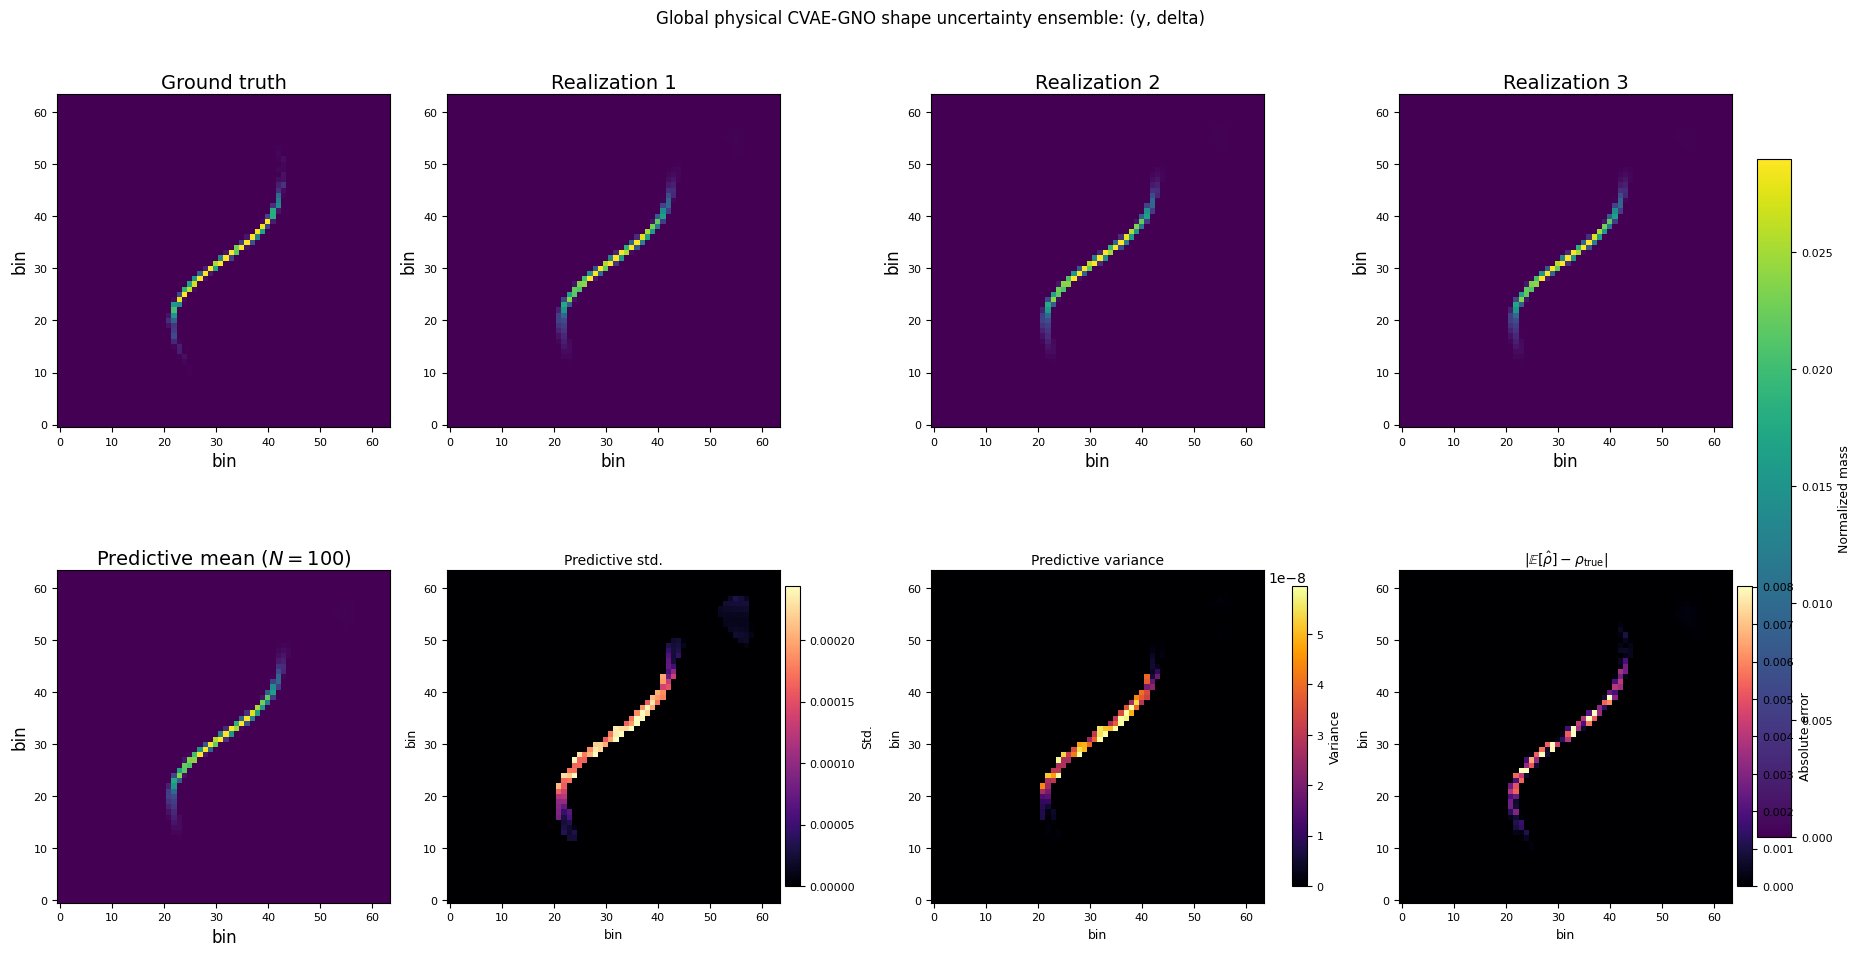

saved: reports/final/structured/images/results/png/global_physical_uncertainty_mass_ensemble.png


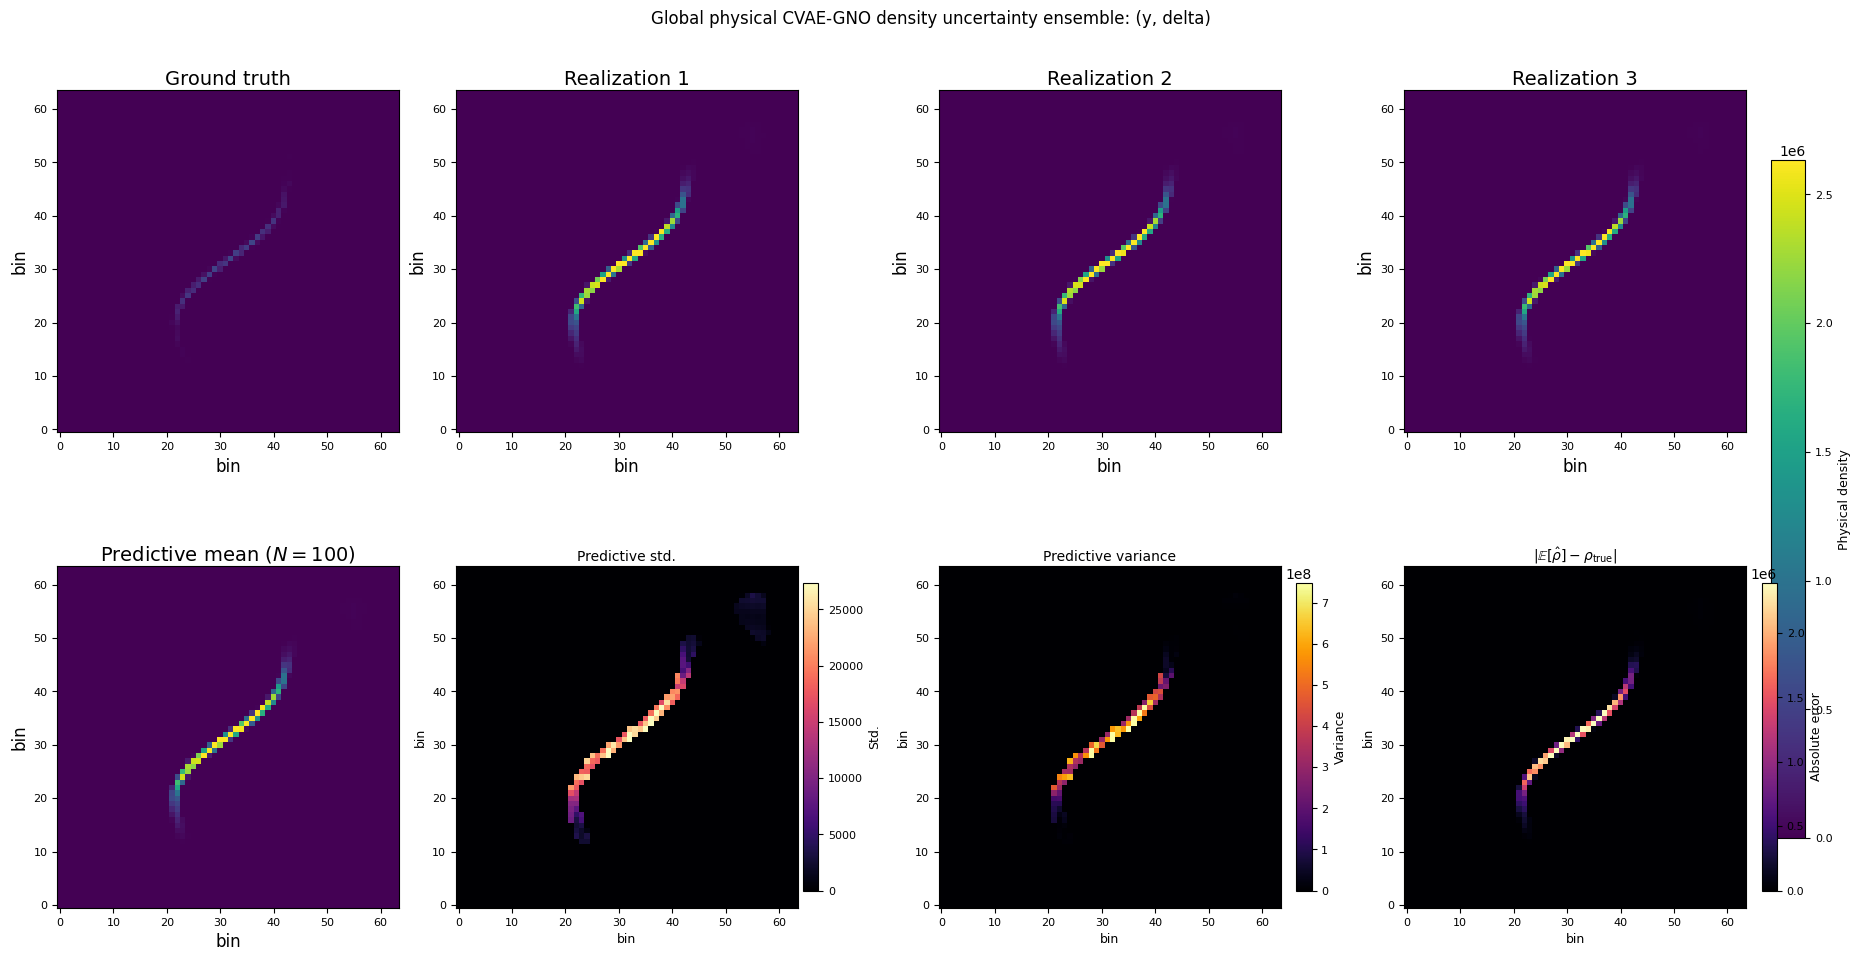

saved: reports/final/structured/images/results/png/global_physical_uncertainty_density_ensemble.png


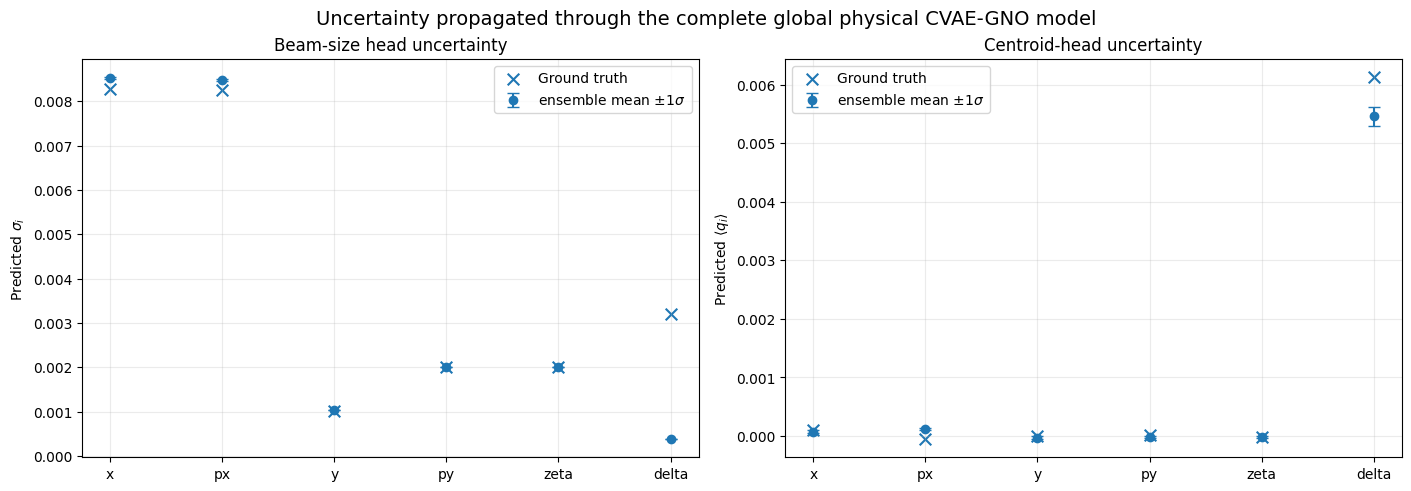

saved: reports/final/structured/images/results/png/global_physical_uncertainty_moments.png

GLOBAL PHYSICAL CVAE-GNO UNCERTAINTY ENSEMBLE
MC draws: 100
Fixed validation sample: 3
Pair index: 11 -> (y, delta)

Normalized-mass uncertainty:
  mean pixel std: 3.748986e-06
  max pixel std:  3.138230e-04
  mean pixel var: 6.816308e-10
  max pixel var:  9.848490e-08
  mean abs error: 7.364131e-05
  max abs error:  1.159624e-02

Physical-density uncertainty:
  mean pixel std: 4.003429e+02
  max pixel std:  3.244647e+04
  mean pixel var: 7.850748e+06
  max pixel var:  1.052774e+09
  mean abs error: 2.222052e+04
  max abs error:  3.394383e+06

Sigma predictive mean:
[0.00852187 0.00847935 0.00104334 0.00200977 0.00200652 0.00037905]
Sigma predictive std:
[2.1702441e-05 1.8186354e-05 6.0244764e-07 5.3910691e-07 6.7226773e-07
 8.1963947e-07]

Centroid predictive mean:
[ 7.6293567e-05  1.1775929e-04 -2.8667353e-05 -1.5432224e-05
 -1.5375463e-05  5.4553999e-03]
Centroid predictive std:
[2.0790396e-0

In [26]:
# ============================================================
# GLOBAL PHYSICAL CVAE+GNO UNCERTAINTY ENSEMBLE
# FOR ONE FIXED INPUT CONDITION
#
# Uses the NEW combined model:
#   model = GlobalPhysicalBeamModel(...)
#
# Uncertainty source:
#   stochastic CVAE posterior sampling inside model.distribution
#
# Each draw propagates through:
#   X_cloud
#      -> CVAE encoder sample z0
#      -> MU conditioning
#      -> GNO tracker
#      -> CVAE decoder shape
#      -> stats head sigma/centroid
#      -> physical density construction
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from beam_global_model import *

# ============================================================
# 1. CONFIGURATION
# ============================================================

N_MC = 100

SAMPLE_IDX = 3
PAIR_IDX = 11        # usually (zeta, delta)

N_ELEM = 3
LATTICE = "fodo"

BASE_SEED = 12345

SAVE_DIR = os.path.join(
    "reports",
    "final",
    "structured",
    "images",
    "results",
    "png",
)

os.makedirs(SAVE_DIR, exist_ok=True)

MASS_FIG = os.path.join(
    SAVE_DIR,
    "global_physical_uncertainty_mass_ensemble.png",
)

DENSITY_FIG = os.path.join(
    SAVE_DIR,
    "global_physical_uncertainty_density_ensemble.png",
)

MOMENT_FIG = os.path.join(
    SAVE_DIR,
    "global_physical_uncertainty_moments.png",
)


# ============================================================
# 2. SMALL HELPERS
# ============================================================

def make_domain_from_mu(MU, model):
    domain_dim = model.distribution.domain_dim
    if MU.shape[1] >= domain_dim:
        return MU[:, :domain_dim]
    return torch.zeros(
        MU.shape[0],
        domain_dim,
        device=MU.device,
        dtype=MU.dtype,
    )


def make_tokens(B, device, lattice="fodo", N_elem=3):
    if lattice == "fodo":
        return make_fodo_lattice_tokens(
            B,
            N_elem,
            device,
        )
    return make_dummy_lattice_tokens(
        B,
        N_elem,
        device,
    )


def to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


# ============================================================
# 3. FIX EXACTLY ONE VALIDATION CONDITION
# ============================================================

model.eval()

X_batch, Y_batch, MU_batch = next(iter(val_loader))

X_batch = X_batch.to(device)
Y_batch = Y_batch.to(device)
MU_batch = MU_batch.to(device)

sample_idx = min(
    SAMPLE_IDX,
    X_batch.shape[0] - 1,
)

X_fixed = X_batch[
    sample_idx:sample_idx + 1
]

Y_fixed = Y_batch[
    sample_idx:sample_idx + 1
]

MU_fixed = MU_batch[
    sample_idx:sample_idx + 1
]

MU_enc_fixed = mu_prep(MU_fixed)

domain_fixed = make_domain_from_mu(
    MU_fixed,
    model,
)

elem_params_fixed, elem_s_fixed = make_tokens(
    B=1,
    device=device,
    lattice=LATTICE,
    N_elem=N_ELEM,
)


# ============================================================
# 4. GROUND TRUTH
# ============================================================

with torch.no_grad():

    truth_mass = cloud_to_pairwise_hists(
        Y_fixed,
        nbins=model.nbins,
        clip_k=model.clip_k,
    )

    centroid_true_t, sigma_true_t = beam_centroid_sigma(
        Y_fixed,
    )

    truth_density, truth_edges = mass_to_physical_density(
        truth_mass,
        sigma_true_t,
        centroid_true_t,
        nbins=model.nbins,
        clip_k=model.clip_k,
    )

    y_mass_truth = (
        truth_mass[0, PAIR_IDX]
        .detach()
        .cpu()
        .numpy()
    )

    y_density_truth = (
        truth_density[0, PAIR_IDX]
        .detach()
        .cpu()
        .numpy()
    )

    sigma_true = (
        sigma_true_t[0]
        .detach()
        .cpu()
        .numpy()
    )

    centroid_true = (
        centroid_true_t[0]
        .detach()
        .cpu()
        .numpy()
    )


# ============================================================
# 5. MONTE-CARLO FORWARD PASSES THROUGH FULL GLOBAL MODEL
# ============================================================

mass_draws = []
density_draws = []
sigma_draws = []
centroid_draws = []

with torch.no_grad():

    for draw_idx in range(N_MC):

        torch.manual_seed(
            BASE_SEED + draw_idx,
        )

        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(
                BASE_SEED + draw_idx,
            )

        out = model(
            X_fixed,
            MU_enc_fixed,
            elem_params_fixed,
            elem_s_fixed,
            domain_fixed,
            sample_vae=True,
            return_physical_density=True,
        )

        mass_draws.append(
            out["histN_mass"][
                0,
                PAIR_IDX,
            ].detach().cpu()
        )

        density_draws.append(
            out["histN_density"][
                0,
                PAIR_IDX,
            ].detach().cpu()
        )

        sigma_draws.append(
            out["sigmaN_hat"][
                0
            ].detach().cpu()
        )

        centroid_draws.append(
            out["centroidN_hat"][
                0
            ].detach().cpu()
        )


# ============================================================
# 6. STACK ENSEMBLE
# ============================================================

mass_draws = torch.stack(
    mass_draws,
    dim=0,
).numpy()

density_draws = torch.stack(
    density_draws,
    dim=0,
).numpy()

sigma_draws = torch.stack(
    sigma_draws,
    dim=0,
).numpy()

centroid_draws = torch.stack(
    centroid_draws,
    dim=0,
).numpy()

print("Mass ensemble shape:", mass_draws.shape)
print("Density ensemble shape:", density_draws.shape)
print("Sigma ensemble shape:", sigma_draws.shape)
print("Centroid ensemble shape:", centroid_draws.shape)


# ============================================================
# 7. ENSEMBLE STATISTICS
# ============================================================

mass_mean = mass_draws.mean(axis=0)
mass_var = mass_draws.var(axis=0, ddof=1)
mass_std = np.sqrt(mass_var)
mass_abs_err = np.abs(mass_mean - y_mass_truth)

density_mean = density_draws.mean(axis=0)
density_var = density_draws.var(axis=0, ddof=1)
density_std = np.sqrt(density_var)
density_abs_err = np.abs(density_mean - y_density_truth)

sigma_mean = sigma_draws.mean(axis=0)
sigma_std = sigma_draws.std(axis=0, ddof=1)

centroid_mean = centroid_draws.mean(axis=0)
centroid_std = centroid_draws.std(axis=0, ddof=1)


# ============================================================
# 8. OLD-NOTEBOOK-STYLE 2x4 ENSEMBLE FIGURE
# ============================================================

def plot_uncertainty_ensemble_2x4(
    truth,
    draws,
    mean,
    std,
    var,
    abs_err,
    pair_idx,
    title_prefix,
    density_label,
    save_path,
):
    pair_i, pair_j = PAIR_INDEX[pair_idx]

    pair_name = (
        f"({COORD_NAMES[pair_i]}, "
        f"{COORD_NAMES[pair_j]})"
    )

    density_stack = np.concatenate(
        [
            truth[None, ...],
            draws[:3],
            mean[None, ...],
        ],
        axis=0,
    )

    vmax_density = max(
        float(np.percentile(density_stack, 99.8)),
        1e-12,
    )

    vmax_std = max(
        float(np.percentile(std, 99.8)),
        1e-12,
    )

    vmax_var = max(
        float(np.percentile(var, 99.8)),
        1e-12,
    )

    vmax_err = max(
        float(np.percentile(abs_err, 99.8)),
        1e-12,
    )

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(18.5, 9.5),
        constrained_layout=True,
    )

    axes = axes.ravel()

    density_panels = [
        (
            truth,
            "Ground truth",
        ),
        (
            draws[0],
            "Realization 1",
        ),
        (
            draws[1],
            "Realization 2",
        ),
        (
            draws[2],
            "Realization 3",
        ),
        (
            mean,
            rf"Predictive mean ($N={N_MC}$)",
        ),
    ]

    last_density_im = None

    for ax, (img, title) in zip(
        axes[:5],
        density_panels,
    ):
        last_density_im = ax.imshow(
            img,
            origin="lower",
            aspect="equal",
            interpolation="nearest",
            cmap="viridis",
            vmin=0.0,
            vmax=vmax_density,
        )

        ax.set_title(
            title,
            fontsize=14,
            pad=4,
        )

        ax.tick_params(
            axis="both",
            labelsize=8,
        )

        ax.set_xlabel(
            "bin",
            fontsize=12,
        )

        ax.set_ylabel(
            "bin",
            fontsize=12,
        )

    im_std = axes[5].imshow(
        std,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="magma",
        vmin=0.0,
        vmax=vmax_std,
    )

    axes[5].set_title(
        "Predictive std.",
        fontsize=10,
        pad=4,
    )

    im_var = axes[6].imshow(
        var,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="inferno",
        vmin=0.0,
        vmax=vmax_var,
    )

    axes[6].set_title(
        "Predictive variance",
        fontsize=10,
        pad=4,
    )

    im_err = axes[7].imshow(
        abs_err,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="magma",
        vmin=0.0,
        vmax=vmax_err,
    )

    axes[7].set_title(
        r"$|\mathbb{E}[\hat{\rho}] - \rho_{\mathrm{true}}|$",
        fontsize=10,
        pad=4,
    )

    for ax in axes[5:]:
        ax.set_xlabel(
            "bin",
            fontsize=9,
        )

        ax.set_ylabel(
            "bin",
            fontsize=9,
        )

        ax.tick_params(
            axis="both",
            labelsize=8,
        )

    cbar_density = fig.colorbar(
        last_density_im,
        ax=axes[:5].tolist(),
        shrink=0.72,
        pad=0.015,
        fraction=0.025,
    )

    cbar_density.set_label(
        density_label,
        fontsize=9,
    )

    cbar_density.ax.tick_params(
        labelsize=8,
    )

    cbar_std = fig.colorbar(
        im_std,
        ax=axes[5],
        shrink=0.78,
        pad=0.015,
        fraction=0.045,
    )

    cbar_std.set_label(
        "Std.",
        fontsize=9,
    )

    cbar_std.ax.tick_params(
        labelsize=8,
    )

    cbar_var = fig.colorbar(
        im_var,
        ax=axes[6],
        shrink=0.78,
        pad=0.015,
        fraction=0.045,
    )

    cbar_var.set_label(
        "Variance",
        fontsize=9,
    )

    cbar_var.ax.tick_params(
        labelsize=8,
    )

    cbar_err = fig.colorbar(
        im_err,
        ax=axes[7],
        shrink=0.78,
        pad=0.015,
        fraction=0.045,
    )

    cbar_err.set_label(
        "Absolute error",
        fontsize=9,
    )

    cbar_err.ax.tick_params(
        labelsize=8,
    )

    fig.suptitle(
        rf"{title_prefix}: {pair_name}",
        fontsize=12,
        y=1.015,
    )

    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("saved:", save_path)


plot_uncertainty_ensemble_2x4(
    truth=y_mass_truth,
    draws=mass_draws,
    mean=mass_mean,
    std=mass_std,
    var=mass_var,
    abs_err=mass_abs_err,
    pair_idx=PAIR_IDX,
    title_prefix="Global physical CVAE-GNO shape uncertainty ensemble",
    density_label="Normalized mass",
    save_path=MASS_FIG,
)

plot_uncertainty_ensemble_2x4(
    truth=y_density_truth,
    draws=density_draws,
    mean=density_mean,
    std=density_std,
    var=density_var,
    abs_err=density_abs_err,
    pair_idx=PAIR_IDX,
    title_prefix="Global physical CVAE-GNO density uncertainty ensemble",
    density_label="Physical density",
    save_path=DENSITY_FIG,
)


# ============================================================
# 9. PHYSICAL MOMENT UNCERTAINTY FIGURE
# ============================================================

coord_labels = list(COORD_NAMES)
coord_idx = np.arange(6)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.8),
    constrained_layout=True,
)

axes[0].errorbar(
    coord_idx,
    sigma_mean,
    yerr=sigma_std,
    fmt="o",
    capsize=4,
    label=r"ensemble mean $\pm 1\sigma$",
)

axes[0].scatter(
    coord_idx,
    sigma_true,
    marker="x",
    s=70,
    label="Ground truth",
)

axes[0].set_xticks(coord_idx)
axes[0].set_xticklabels(coord_labels)
axes[0].set_title("Beam-size head uncertainty")
axes[0].set_ylabel(r"Predicted $\sigma_i$")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].errorbar(
    coord_idx,
    centroid_mean,
    yerr=centroid_std,
    fmt="o",
    capsize=4,
    label=r"ensemble mean $\pm 1\sigma$",
)

axes[1].scatter(
    coord_idx,
    centroid_true,
    marker="x",
    s=70,
    label="Ground truth",
)

axes[1].set_xticks(coord_idx)
axes[1].set_xticklabels(coord_labels)
axes[1].set_title("Centroid-head uncertainty")
axes[1].set_ylabel(r"Predicted $\langle q_i \rangle$")
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.suptitle(
    "Uncertainty propagated through the complete global physical CVAE-GNO model",
    fontsize=14,
)

fig.savefig(
    MOMENT_FIG,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("saved:", MOMENT_FIG)


# ============================================================
# 10. NUMERICAL SUMMARY
# ============================================================

pair_i, pair_j = PAIR_INDEX[PAIR_IDX]
pair_name = f"({COORD_NAMES[pair_i]}, {COORD_NAMES[pair_j]})"

print()
print("=" * 78)
print("GLOBAL PHYSICAL CVAE-GNO UNCERTAINTY ENSEMBLE")
print("=" * 78)
print(f"MC draws: {N_MC}")
print(f"Fixed validation sample: {sample_idx}")
print(f"Pair index: {PAIR_IDX} -> {pair_name}")
print()

print("Normalized-mass uncertainty:")
print(f"  mean pixel std: {mass_std.mean():.6e}")
print(f"  max pixel std:  {mass_std.max():.6e}")
print(f"  mean pixel var: {mass_var.mean():.6e}")
print(f"  max pixel var:  {mass_var.max():.6e}")
print(f"  mean abs error: {mass_abs_err.mean():.6e}")
print(f"  max abs error:  {mass_abs_err.max():.6e}")
print()

print("Physical-density uncertainty:")
print(f"  mean pixel std: {density_std.mean():.6e}")
print(f"  max pixel std:  {density_std.max():.6e}")
print(f"  mean pixel var: {density_var.mean():.6e}")
print(f"  max pixel var:  {density_var.max():.6e}")
print(f"  mean abs error: {density_abs_err.mean():.6e}")
print(f"  max abs error:  {density_abs_err.max():.6e}")
print()

print("Sigma predictive mean:")
print(sigma_mean)
print("Sigma predictive std:")
print(sigma_std)
print()

print("Centroid predictive mean:")
print(centroid_mean)
print("Centroid predictive std:")
print(centroid_std)
print()

print("Ground-truth sigma:")
print(sigma_true)
print()

print("Ground-truth centroid:")
print(centroid_true)
print()

print("Saved figures:")
print(MASS_FIG)
print(DENSITY_FIG)
print(MOMENT_FIG)
print("=" * 78)

In [ ]:
# ============================================================
# 8. FIVE-PANEL UNCERTAINTY FIGURE
# truth | E[rho] | Var[rho] | Std[rho] | |E[rho] - truth|
# ============================================================

def plot_uncertainty_5panel(
    truth,
    mean,
    std,
    var,
    abs_err,
    pair_idx,
    title_prefix,
    density_label,
    save_path,
):
    pair_i, pair_j = PAIR_INDEX[pair_idx]

    pair_name = (
        f"({COORD_NAMES[pair_i]}, "
        f"{COORD_NAMES[pair_j]})"
    )

    density_stack = np.stack(
        [
            truth,
            mean,
        ],
        axis=0,
    )

    vmax_density = max(
        float(np.percentile(density_stack, 99.8)),
        1e-12,
    )

    vmax_var = max(
        float(np.percentile(var, 99.8)),
        1e-12,
    )

    vmax_std = max(
        float(np.percentile(std, 99.8)),
        1e-12,
    )

    vmax_err = max(
        float(np.percentile(abs_err, 99.8)),
        1e-12,
    )

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(22.0, 4.6),
        constrained_layout=True,
    )

    # --------------------------------------------------------
    # 1. Truth
    # --------------------------------------------------------
    im_true = axes[0].imshow(
        truth,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="viridis",
        vmin=0.0,
        vmax=vmax_density,
    )

    axes[0].set_title(
        r"$\rho_{\mathrm{true}}$",
        fontsize=15,
        pad=8,
    )

    # --------------------------------------------------------
    # 2. Ensemble mean
    # --------------------------------------------------------
    im_mean = axes[1].imshow(
        mean,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="viridis",
        vmin=0.0,
        vmax=vmax_density,
    )

    axes[1].set_title(
        r"$\mathbb{E}[\hat{\rho}]$",
        fontsize=15,
        pad=8,
    )

    # --------------------------------------------------------
    # 3. Variance
    # --------------------------------------------------------
    im_var = axes[2].imshow(
        var,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="inferno",
        vmin=0.0,
        vmax=vmax_var,
    )

    axes[2].set_title(
        r"$\mathrm{Var}[\hat{\rho}]$",
        fontsize=15,
        pad=8,
    )

    # --------------------------------------------------------
    # 4. Standard deviation
    # --------------------------------------------------------
    im_std = axes[3].imshow(
        std,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="magma",
        vmin=0.0,
        vmax=vmax_std,
    )

    axes[3].set_title(
        r"$\mathrm{Std}[\hat{\rho}]$",
        fontsize=15,
        pad=8,
    )

    # --------------------------------------------------------
    # 5. Absolute error
    # --------------------------------------------------------
    im_err = axes[4].imshow(
        abs_err,
        origin="lower",
        aspect="equal",
        interpolation="nearest",
        cmap="magma",
        vmin=0.0,
        vmax=vmax_err,
    )

    axes[4].set_title(
        r"$|\mathbb{E}[\hat{\rho}] - \rho_{\mathrm{true}}|$",
        fontsize=15,
        pad=8,
    )

    # --------------------------------------------------------
    # Axes style
    # --------------------------------------------------------
    for ax in axes:
        ax.set_xlabel(
            "Horizontal bin index",
            fontsize=13,
        )

        ax.set_ylabel(
            "Vertical bin index",
            fontsize=13,
        )

        ax.tick_params(
            axis="both",
            labelsize=11,
            length=5,
            width=1.2,
        )

    # --------------------------------------------------------
    # Colorbars
    # --------------------------------------------------------
    cbar_density = fig.colorbar(
        im_mean,
        ax=[axes[0], axes[1]],
        shrink=0.80,
        pad=0.015,
        fraction=0.040,
    )

    cbar_density.set_label(
        density_label,
        fontsize=12,
    )

    cbar_density.ax.tick_params(
        labelsize=10,
    )

    cbar_var = fig.colorbar(
        im_var,
        ax=axes[2],
        shrink=0.80,
        pad=0.015,
        fraction=0.050,
    )

    cbar_var.set_label(
        "Variance",
        fontsize=12,
    )

    cbar_var.ax.tick_params(
        labelsize=10,
    )

    cbar_std = fig.colorbar(
        im_std,
        ax=axes[3],
        shrink=0.80,
        pad=0.015,
        fraction=0.050,
    )

    cbar_std.set_label(
        "Std.",
        fontsize=12,
    )

    cbar_std.ax.tick_params(
        labelsize=10,
    )

    cbar_err = fig.colorbar(
        im_err,
        ax=axes[4],
        shrink=0.80,
        pad=0.015,
        fraction=0.050,
    )

    cbar_err.set_label(
        "Absolute error",
        fontsize=12,
    )

    cbar_err.ax.tick_params(
        labelsize=10,
    )

    fig.suptitle(
        rf"{title_prefix}: {pair_name}",
        fontsize=15,
        y=1.05,
    )

    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("saved:", save_path)